In [1]:
import os
import sys
import math
import random
import torch

sys.path.append("..")
from io import BytesIO
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import requests
import zarr
import matplotlib.pyplot as plt
from PIL import Image
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from torch.utils.data import DataLoader

from utils.DataProcessing import MultimodalDataset
from utils.AstroImageFunctions import make_rgb
from models.MAE import MaskedAutoencoderViT

from utils.DataProcessing import (
    generate_rest_indices,
    get_extreme_mask,
    get_kernel,
    safe_collate,
    smooth_data,
    MultimodalDataset,
    CreateMultimodalDataLoadersIter,
)

/global/cfs/cdirs/desi/users/pzehao/envs/peng/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_loader, val_loader, test_loader = CreateMultimodalDataLoadersIter(end=4737442, train_size=4642694, batch_size=32)

In [3]:
import math
import random

import numpy as np
import pytorch_lightning as pl
import torch
import torch.nn as nn
from timm.models.vision_transformer import PatchEmbed

from losses.SpecLoss import forward_loss
from models.MyTimm import Block, generate_attn_mask, PatchEmbed1D
from utils.DataProcessing import generate_rest_indices
from utils.PositionalEmbedding import get_1d_sincos_pos_embed, get_2d_sincos_pos_embed
from utils.Scheduler import CosineWarmupScheduler
from utils.Visualization import visualize


class MaskedAutoencoderViT(pl.LightningModule):
    """ Masked Autoencoder with VisionTransformer backbone, copied from https://github.com/facebookresearch/mae/blob/main/models_mae.py 
    """

    def __init__(
        self,
        spec_dim=7781,
        patch_size=31,
        left_patches=10,
        right_patches=10,
        embed_dim=768,
        merged_depth=6,
        merged_num_heads=6,
        s_depth=1,
        e_depth=1,
        s_num_heads=1,
        e_num_heads=1,
        decoder_embed_dim=384,
        decoder_depth=2,
        decoder_num_heads=6,
        decoder_MLP_coefficient=4,
        lr=2e-4,
        warmup_epoch=100,
        max_epochs=3000,
        batch_size=16,
        mlp_ratio=4.0,
        mask_ratio=0.75,
        patch_scheme={"patch_sizes": [1], "mask_ratios": [0.75]},
        scatter_term=1,
        log_regularizer=1.0,
        lam_grad=0.0,
        lam_curv=0.0,
        lam_fft=0.0,
        lam_topk=0.0,
        topk_frac=0.10,
        lam_spiky=0.0,
        spiky_tau=0.8,
        lam_under=0.0,
        lam_sigma_right=0.0,
        sigma_quantile=0.75,
        lam_img_sigma_masked=0.0,
        norm_layer=nn.LayerNorm,
        norm_pix_loss=False,
    ):
        super().__init__()
        self.save_hyperparameters()

        # --------------------------------------------------------------------------
        # MAE encoder specifics
        self.patch_embed1d = PatchEmbed1D(spec_dim, patch_size, embed_dim)
        self.img_patch = 16
        self.num_img_channels = 6
        self.patch_embedimg = PatchEmbed(img_size=128, patch_size=self.img_patch, in_chans=1, embed_dim=embed_dim)
        self.num_patches1d = self.patch_embed1d.num_patches
        self.num_patchesimg = self.patch_embedimg.num_patches * self.num_img_channels
        self.left_patches = left_patches
        self.right_patches = right_patches

        # --- image positional embeddings (spatial + channel + modality) ---
        self.num_img_spatial = self.patch_embedimg.num_patches
        img_grid_size = int(math.sqrt(self.num_img_spatial))
        if img_grid_size * img_grid_size != self.num_img_spatial:
            raise ValueError(f"Image patch grid is not square: {self.num_img_spatial}")

        self.register_buffer(
            "img_channel_embed",
            self._build_fixed_channel_embed(self.num_img_channels, embed_dim),
            persistent=False,
        )
        self.img_modality_embed = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.img_e_modality_embed = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.register_buffer(
            "img_spatial_pos_embed",
            get_2d_sincos_pos_embed(embed_dim, img_grid_size, img_grid_size),
            persistent=False,
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 10000 + 1, embed_dim), requires_grad=False)

        self.s_attn = nn.ModuleList([
            Block(embed_dim, s_num_heads, mlp_ratio, qkv_bias=True, norm_layer=norm_layer)
            for _ in range(s_depth)
        ])
        self.e_attn = nn.ModuleList([
            Block(embed_dim, e_num_heads, mlp_ratio, qkv_bias=True, norm_layer=norm_layer)
            for _ in range(e_depth)
        ])
        self.img_attn = nn.ModuleList([
            Block(embed_dim, s_num_heads, mlp_ratio, qkv_bias=True, norm_layer=norm_layer)
            for _ in range(s_depth)
        ])
        self.img_e_attn = nn.ModuleList([
            Block(embed_dim, e_num_heads, mlp_ratio, qkv_bias=True, norm_layer=norm_layer)
            for _ in range(e_depth)
        ])

        self.merged_blocks = nn.ModuleList([
            Block(2 * embed_dim, merged_num_heads, mlp_ratio, qkv_bias=True, norm_layer=norm_layer)
            for _ in range(merged_depth)
        ]) # Attention blocks for merged spectra and images
        self.norm = norm_layer(embed_dim)
        self.merged_norm = norm_layer(2 * embed_dim)
        # --------------------------------------------------------------------------

        # --------------------------------------------------------------------------
        # MAE decoder specifics
        self.decoder_embed = nn.Linear(embed_dim * 2, decoder_embed_dim, bias=True)

        self.spec_mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.img_mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))

        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, 10000 + 1, decoder_embed_dim), requires_grad=False)

        # --- decoder image positional embeddings (spatial + channel + modality) ---
        self.register_buffer(
            "decoder_img_channel_embed",
            self._build_fixed_channel_embed(self.num_img_channels, decoder_embed_dim),
            persistent=False,
        )
        self.decoder_img_modality_embed = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.register_buffer(
            "decoder_img_spatial_pos_embed",
            get_2d_sincos_pos_embed(decoder_embed_dim, img_grid_size, img_grid_size),
            persistent=False,
        )

        self.decoder_blocks = nn.ModuleList([
            Block(decoder_embed_dim, decoder_num_heads, mlp_ratio, qkv_bias=True, norm_layer=norm_layer)
            for _ in range(decoder_depth)
        ])

        self.decoder_norm = norm_layer(decoder_embed_dim)
        self.decoder_pred = nn.Sequential(
            nn.Linear(decoder_embed_dim, decoder_MLP_coefficient * decoder_embed_dim),
            nn.GELU(),
            nn.Linear(decoder_MLP_coefficient * decoder_embed_dim, decoder_MLP_coefficient * decoder_embed_dim),
            nn.GELU(),
            nn.Linear(decoder_MLP_coefficient * decoder_embed_dim, patch_size),
        )

        self.decoder_e_estimator = nn.Sequential(
            nn.Linear(decoder_embed_dim, decoder_MLP_coefficient * decoder_embed_dim),
            nn.GELU(),
            nn.Linear(decoder_MLP_coefficient * decoder_embed_dim, decoder_MLP_coefficient * decoder_embed_dim),
            nn.GELU(),
            nn.Linear(decoder_MLP_coefficient * decoder_embed_dim, patch_size),
        )

        self.decoder_pred_img = nn.Sequential(
            nn.Linear(decoder_embed_dim, decoder_MLP_coefficient * decoder_embed_dim),
            nn.GELU(),
            nn.Linear(decoder_MLP_coefficient * decoder_embed_dim, decoder_MLP_coefficient * decoder_embed_dim),
            nn.GELU(),
            nn.Linear(decoder_MLP_coefficient * decoder_embed_dim, self.img_patch * self.img_patch),
        )

        self.decoder_pred_img_e = nn.Sequential(
            nn.Linear(decoder_embed_dim, decoder_MLP_coefficient * decoder_embed_dim),
            nn.GELU(),
            nn.Linear(decoder_MLP_coefficient * decoder_embed_dim, decoder_MLP_coefficient * decoder_embed_dim),
            nn.GELU(),
            nn.Linear(decoder_MLP_coefficient * decoder_embed_dim, self.img_patch * self.img_patch),
        )

        refiner_hidden = 32
        self.decoder_img_refiner = nn.Sequential(
            nn.Conv2d(self.num_img_channels, refiner_hidden, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(refiner_hidden, refiner_hidden, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(refiner_hidden, refiner_hidden, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(refiner_hidden, self.num_img_channels, kernel_size=3, padding=1),
        )
        self.decoder_img_e_refiner = nn.Sequential(
            nn.Conv2d(self.num_img_channels, refiner_hidden, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(refiner_hidden, refiner_hidden, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(refiner_hidden, refiner_hidden, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(refiner_hidden, self.num_img_channels, kernel_size=3, padding=1),
        )
        # --------------------------------------------------------------------------

        self.norm_pix_loss = norm_pix_loss
        self.mask_ratio = mask_ratio
        self.mask_ratio_img = 0.75
        self.lr = lr
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.chunk_size = 1
        self.patch_scheme = patch_scheme
        self.warmup_epoch = warmup_epoch

        self.lambda_min_obs = 3600 - 0.8 * self.patch_size * self.left_patches
        self.lambda_max_obs = 9824 + 0.8 * self.patch_size * self.right_patches
        self.spec_dim = spec_dim

        # ---------------------------------------------------------------------------
        # Loss function parameters
        self.scatter_term = scatter_term
        self.log_regularizer = log_regularizer
        self.lam_grad = lam_grad
        self.lam_curv = lam_curv
        self.lam_fft = lam_fft
        self.lam_topk = lam_topk
        self.topk_frac = topk_frac
        self.lam_spiky = lam_spiky
        self.spiky_tau = spiky_tau
        self.lam_under = lam_under
        self.lam_sigma_right = lam_sigma_right
        self.sigma_quantile = sigma_quantile
        self.lam_img_sigma_masked = lam_img_sigma_masked

        # extras

        self.coord_mlp = nn.Sequential(
            nn.Linear(2, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, embed_dim),
        )
        self.decoder_coord_mlp = nn.Sequential(
            nn.Linear(2, decoder_embed_dim),
            nn.GELU(),
            nn.Linear(decoder_embed_dim, decoder_embed_dim),
        )

        self.img_spatial_pos_embed = get_2d_sincos_pos_embed(self.hparams.embed_dim, img_grid_size, img_grid_size)
        self.decoder_img_spatial_pos_embed = get_2d_sincos_pos_embed(
            self.hparams.decoder_embed_dim, img_grid_size, img_grid_size
        )

        self.initialize_weights()

    def initialize_weights(self):
        ###
        pos_embed = get_1d_sincos_pos_embed(self.pos_embed.shape[-1], 10000, cls_token=True)
        self.pos_embed.data.copy_(torch.from_numpy(pos_embed).float().unsqueeze(0))

        decoder_pos_embed = get_1d_sincos_pos_embed(self.decoder_pos_embed.shape[-1], 10000, cls_token=True)
        self.decoder_pos_embed.data.copy_(torch.from_numpy(decoder_pos_embed).float().unsqueeze(0))
        ### freeze sin cos PE

        # initialization
        # initialize patch_embed like nn.Linear (instead of nn.Conv2d)
        w = self.patch_embed1d.proj.weight.data
        torch.nn.init.xavier_uniform_(w.view([w.shape[0], -1]))

        # timm's trunc_normal_(std=.02) is effectively normal_(std=0.02) as cutoff is too big (2.)
        torch.nn.init.normal_(self.cls_token, std=0.02)
        torch.nn.init.normal_(self.spec_mask_token, std=0.02)
        torch.nn.init.normal_(self.img_mask_token, std=0.02)

        # torch.nn.init.normal_(self.img_channel_embed.weight, std=.02)
        torch.nn.init.normal_(self.img_modality_embed, std=0.02)
        torch.nn.init.normal_(self.img_e_modality_embed, std=0.02)
        # torch.nn.init.normal_(self.decoder_img_channel_embed.weight, std=.02)
        torch.nn.init.normal_(self.decoder_img_modality_embed, std=0.02)

        # initialize nn.Linear and nn.LayerNorm
        self.apply(self._init_weights)

    def _build_fixed_channel_embed(self, num_channels, embed_dim):
        if embed_dim % 2 != 0:
            raise ValueError(f"embed_dim must be even for fixed channel embeddings, got {embed_dim}")
        channel_ids = torch.arange(num_channels, dtype=torch.float32).unsqueeze(1)
        dim_half = embed_dim // 2
        omega = torch.arange(dim_half, dtype=torch.float32)
        omega = 1.0 / (10000.0 ** (omega / dim_half))
        out = channel_ids * omega.unsqueeze(0)
        return torch.cat([torch.sin(out), torch.cos(out)], dim=1)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            # we use xavier_uniform following official JAX ViT:
            torch.nn.init.xavier_uniform_(m.weight)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def get_image_pos_embed(self, dtype, device):
        spatial = self.img_spatial_pos_embed.to(device=device, dtype=dtype)
        spatial = spatial.expand(self.num_img_channels, -1, -1)

        channel = self.img_channel_embed.to(device=device, dtype=dtype)
        channel = channel.unsqueeze(1).expand(-1, self.num_img_spatial, -1)

        img_pos = (spatial + channel).reshape(1, self.num_img_channels * self.num_img_spatial, -1)
        return img_pos

    def get_decoder_image_pos_embed(self, dtype, device):
        spatial = self.decoder_img_spatial_pos_embed.to(device=device, dtype=dtype)
        spatial = spatial.expand(self.num_img_channels, -1, -1)

        channel = self.decoder_img_channel_embed.to(device=device, dtype=dtype)
        channel = channel.unsqueeze(1).expand(-1, self.num_img_spatial, -1)

        img_pos = (spatial + channel).reshape(1, self.num_img_channels * self.num_img_spatial, -1)
        return img_pos

    def _continuous_2d_sincos(self, xy_patch_units, embed_dim, dtype, device):
        # Used to generate PEs for spectrum based on fibre location, to match image sin cos PE
        if embed_dim % 4 != 0:
            raise ValueError(f"embed_dim must be divisible by 4, got {embed_dim}")
        xy = xy_patch_units.to(device=device, dtype=dtype)
        x = xy[:, 0:1]
        y = xy[:, 1:2]
        dim_each = embed_dim // 4
        omega = torch.arange(dim_each, device=device, dtype=dtype)
        omega = 1.0 / (10000.0 ** (omega / dim_each))
        out_x = x * omega.unsqueeze(0)
        out_y = y * omega.unsqueeze(0)
        return torch.cat([torch.sin(out_x), torch.cos(out_x), torch.sin(out_y), torch.cos(out_y)], dim=-1)

    def _build_relative_patch_coords(self, xy_pix, dtype, device):
        # Returns relative coords of image patch to centre patch in patch units
        gh, gw = self.patch_embedimg.grid_size
        p_h, p_w = self.patch_embedimg.patch_size
        H, W = self.patch_embedimg.img_size

        row_centers = torch.arange(gh, device=device, dtype=dtype) * p_h + (p_h - 1) / 2.0
        col_centers = torch.arange(gw, device=device, dtype=dtype) * p_w + (p_w - 1) / 2.0

        x_centers = col_centers - (W - 1) / 2.0
        y_centers = (H - 1) / 2.0 - row_centers

        yy, xx = torch.meshgrid(y_centers, x_centers, indexing="ij")
        patch_xy = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=-1)

        xy = xy_pix.to(device=device, dtype=dtype)
        rel_xy = patch_xy.unsqueeze(0) - xy.unsqueeze(1)
        return rel_xy / float(p_w)

    def _img_tokens_to_image(self, tokens):
        B = tokens.shape[0]
        gh, gw = self.patch_embedimg.grid_size
        p_h, p_w = self.patch_embedimg.patch_size
        x = tokens.view(B, self.num_img_channels, gh * gw, p_h * p_w)
        x = x.view(B, self.num_img_channels, gh, gw, p_h, p_w)
        x = x.permute(0, 1, 2, 4, 3, 5).reshape(B, self.num_img_channels, gh * p_h, gw * p_w)
        return x

    def _image_to_img_tokens(self, img):
        B = img.shape[0]
        gh, gw = self.patch_embedimg.grid_size
        p_h, p_w = self.patch_embedimg.patch_size
        x = img.view(B, self.num_img_channels, gh, p_h, gw, p_w)
        x = x.permute(0, 1, 2, 4, 3, 5).reshape(B, self.num_img_channels, gh * gw, p_h * p_w)
        return x.reshape(B, self.num_patchesimg, p_h * p_w)

    def _refine_img_tokens(self, tokens, refiner):
        img = self._img_tokens_to_image(tokens)
        img = refiner(img)
        return self._image_to_img_tokens(img)

    def _restore_masked_tokens(self, visible_tokens, keep_mask, mask_token):
        B = visible_tokens.shape[0]
        full_tokens = mask_token.to(dtype=visible_tokens.dtype, device=visible_tokens.device).repeat(
            B, keep_mask.numel(), 1
        )
        keep_idx = keep_mask.nonzero(as_tuple=False).squeeze(1)
        full_tokens[:, keep_idx, :] = visible_tokens
        return full_tokens

    def forward_encoder(self, s, e, img, img_e, z, xy_pix, mask_ratio, chunk_size):
        s = self.patch_embed1d(s.unsqueeze(-1))
        e = self.patch_embed1d(e.unsqueeze(-1))

        # I'm going to hardcode 128 size assumption here for now
        xy_grid_x = (xy_pix[:, 0] + 64.0) / self.img_patch
        xy_grid_y = (64.0 - xy_pix[:, 1]) / self.img_patch
        xy_grid = torch.stack([xy_grid_x, xy_grid_y], dim=-1)

        xy_pe = self._continuous_2d_sincos(xy_grid, self.hparams.embed_dim, s.dtype, s.device).unsqueeze(1)

        s = s + xy_pe
        e = e + xy_pe

        rel_coords = self._build_relative_patch_coords(xy_pix, dtype=img.dtype, device=img.device)
        coord_emb = self.coord_mlp(rel_coords)
        img = torch.cat([self.patch_embedimg(img[:, i:i + 1]) + coord_emb for i in range(img.size(1))], dim=1)
        img_e = torch.cat([self.patch_embedimg(img_e[:, i:i + 1]) + coord_emb for i in range(img_e.size(1))], dim=1)

        img_pos_embed = self.get_image_pos_embed(dtype=img.dtype, device=img.device)
        img = img + img_pos_embed + self.img_modality_embed.to(dtype=img.dtype)
        img_e = img_e + img_pos_embed + self.img_e_modality_embed.to(dtype=img_e.dtype)

        deredshifted_start_indices, deredshifted_end_indices = generate_rest_indices(s, z, patch_size=self.patch_size)
        pos_table = self.pos_embed[:, 1:, :].squeeze(0)
        pe_start = pos_table[deredshifted_start_indices]
        pe_end = pos_table[deredshifted_end_indices]
        s = s + pe_start + pe_end
        e = e + pe_start + pe_end

        token_mask = generate_attn_mask(
            chunk_size,
            mask_ratio,
            self.num_patches1d + 1,
            device=s.device,
            return_attn_mask=False,
        )
        token_mask_img = generate_attn_mask(
            1,
            self.mask_ratio_img,
            self.num_patchesimg,
            device=s.device,
            return_attn_mask=False,
        )

        # Keep CLS token always visible.
        token_mask = token_mask.clone()
        token_mask[0] = False

        cls_token = self.cls_token + self.pos_embed[:, 0, :]
        cls_tokens = cls_token.expand(s.shape[0], -1, -1)
        s = torch.cat((cls_tokens, s), dim=1)
        e = torch.cat((cls_tokens, e), dim=1)

        spec_keep = ~token_mask
        img_keep = ~token_mask_img

        # Canonical MAE behavior: drop masked tokens before encoder blocks.
        s = s[:, spec_keep, :]
        e = e[:, spec_keep, :]
        img = img[:, img_keep, :]
        img_e = img_e[:, img_keep, :]

        for blk in self.s_attn:
            s = blk(s)
        s = self.norm(s)

        for blk in self.e_attn:
            e = blk(e)
        e = self.norm(e)

        for blk in self.img_attn:
            img = blk(img)
        img = self.norm(img)

        for blk in self.img_e_attn:
            img_e = blk(img_e)
        img_e = self.norm(img_e)

        x = torch.cat([s, e], dim=-1)
        x_img = torch.cat([img, img_e], dim=-1)
        x = torch.cat([x, x_img], dim=1)

        overall_token_mask = torch.cat([token_mask, token_mask_img], dim=0)

        for blk in self.merged_blocks:
            x = blk(x)
        x = self.merged_norm(x)

        return x, None, overall_token_mask, None, None

    def forward_decoder(self, x, token_mask, z, xy_pix):
        x = self.decoder_embed(x)

        spec_mask = token_mask[:-self.num_patchesimg].bool()
        img_mask = token_mask[-self.num_patchesimg:].bool()

        spec_keep = ~spec_mask
        img_keep = ~img_mask
        num_spec_visible = int(spec_keep.sum().item())
        x_spec_visible = x[:, :num_spec_visible, :]
        x_img_visible = x[:, num_spec_visible:, :]

        x_spec = self._restore_masked_tokens(x_spec_visible, spec_keep, self.spec_mask_token)
        x_img = self._restore_masked_tokens(x_img_visible, img_keep, self.img_mask_token)
        x = torch.cat([x_spec, x_img], dim=1)

        B, _, _ = x.shape
        left_tokens = self.spec_mask_token.repeat(B, self.left_patches, 1)
        right_tokens = self.spec_mask_token.repeat(B, self.right_patches, 1)

        cls_token = x[:, :1, :]
        main_seq = x[:, 1:-self.num_patchesimg, :]
        img_seq = x[:, -self.num_patchesimg:, :]
        padded_seq = torch.cat([left_tokens, main_seq, right_tokens, img_seq], dim=1)
        x = torch.cat([cls_token, padded_seq], dim=1)

        pos_table = self.decoder_pos_embed[:, 1:, :].squeeze(0)

        spec_len = x.shape[1] - 1 - self.num_patchesimg
        x_spec = x[:, 1:1 + spec_len, :]
        x_img = x[:, -self.num_patchesimg:, :]

        x_for_pe = x[:, :1 + spec_len, :]
        deredshifted_start_indices, deredshifted_end_indices = generate_rest_indices(
            x_for_pe,
            z,
            lambda_min_obs=self.lambda_min_obs,
            patch_size=self.patch_size,
        )

        pe_start = pos_table[deredshifted_start_indices]
        pe_end = pos_table[deredshifted_end_indices]
        x_spec = x_spec + pe_start[:, 1:, :] + pe_end[:, 1:, :]
        xy_grid_x = (xy_pix[:, 0] + 64.0) / self.img_patch
        xy_grid_y = (64.0 - xy_pix[:, 1]) / self.img_patch
        xy_grid = torch.stack([xy_grid_x, xy_grid_y], dim=-1)
        xy_pe = self._continuous_2d_sincos(xy_grid, self.hparams.decoder_embed_dim, x.dtype, x.device).unsqueeze(1)
        x_spec = x_spec + xy_pe

        img_pos = self.get_decoder_image_pos_embed(dtype=x.dtype, device=x.device)
        rel_coords = self._build_relative_patch_coords(xy_pix, dtype=x.dtype, device=x.device)
        coord_emb = self.decoder_coord_mlp(rel_coords).repeat(1, self.num_img_channels, 1)
        x_img = x_img + img_pos + self.decoder_img_modality_embed.to(dtype=x.dtype) + coord_emb

        x = torch.cat([x[:, :1, :], x_spec, x_img], dim=1)

        for blk in self.decoder_blocks:
            x = blk(x)
        x = self.decoder_norm(x)

        s = self.decoder_pred(x[:, :-self.num_patchesimg, :])
        e = self.decoder_e_estimator(x[:, :-self.num_patchesimg, :])
        img = self.decoder_pred_img(x[:, -self.num_patchesimg:, :])
        img_e = self.decoder_pred_img_e(x[:, -self.num_patchesimg:, :])
        img = self._refine_img_tokens(img, self.decoder_img_refiner)
        img_e = self._refine_img_tokens(img_e, self.decoder_img_e_refiner)

        s = s[:, 1:, :].view(s.shape[0], -1)
        e = e[:, 1:, :].view(e.shape[0], -1)
        img = img.view(img.shape[0], -1)
        img_e = img_e.view(img_e.shape[0], -1)

        return s, e, img, img_e

    def forward(self, spec, weig, error, img, weig_img, error_img, z, xy_pix):
        latent, _, token_mask, _, _ = self.forward_encoder(
            spec, error, img, error_img, z, xy_pix, self.mask_ratio, self.chunk_size
        )
        pred, error, pred_img, error_img = self.forward_decoder(latent, token_mask, z, xy_pix)

        offset = self.left_patches * self.patch_size
        spec_loss, img_loss, total_loss = forward_loss(
            pred[:, offset:offset + self.spec_dim],
            spec,
            weig,
            error[:, offset:offset + self.spec_dim],
            pred_img,
            img,
            weig_img,
            error_img,
            token_mask[:-self.num_patchesimg].long(),
            img_mask=token_mask[-self.num_patchesimg:].long(),
            num_patches1d=self.num_patches1d,
            left_patches=self.left_patches,
            patch_size=self.patch_size,
            img_patch=self.img_patch,
            num_img_channels=self.num_img_channels,
            num_img_patches=self.patch_embedimg.num_patches,
            weight=self.scatter_term,
            regularizer=self.log_regularizer,
            lam_grad=self.lam_grad,
            lam_curv=self.lam_curv,
            lam_topk=self.lam_topk,
            lam_fft=self.lam_fft,
            topk_frac=self.topk_frac,
            lam_spiky=self.lam_spiky,
            spiky_tau=self.spiky_tau,
            lam_under=self.lam_under,
            lam_sigma_right=self.lam_sigma_right,
            lam_img_sigma_masked=self.lam_img_sigma_masked,
        )
        return spec_loss, img_loss, total_loss, pred, error, pred_img, error_img, token_mask

    def training_step(self, batch, batch_idx):
        zero_loss = sum((p.sum() * 0.0) for p in self.parameters() if p.requires_grad)

        if batch is None:
            print(f"Empty batch at step {batch_idx}; using zero loss")
            return zero_loss

        self.chunk_size, self.mask_ratio = self.sample_patching()
        _, mask_ratio_img = self.sample_patching()
        if mask_ratio_img == self.mask_ratio and mask_ratio_img == 1:
            mask_ratio_img = 0.9
        self.mask_ratio_img = mask_ratio_img
        self.log("chunk_size", self.chunk_size)
        self.log("mask_ratio", self.mask_ratio)
        self.log("mask_ratio_img", self.mask_ratio_img)

        x, spec, weig, error, img, img_w, img_e, z, xy_pix = batch
        spec_loss, img_loss, total_loss, _, _, _, _, _ = self.forward(spec, weig, error, img, img_w, img_e, z, xy_pix)

        if not torch.isfinite(total_loss):
            print(f"Non-finite loss at step {batch_idx}; using zero loss")
            return zero_loss

        self.log("train_loss", total_loss, on_step=True, on_epoch=True, prog_bar=True, sync_dist=True)
        self.log("spec_loss", spec_loss, on_step=True, on_epoch=True, prog_bar=False, sync_dist=True)
        self.log("img_loss", img_loss, on_step=True, on_epoch=True, prog_bar=False, sync_dist=True)
        self.log("grad_norm", self._grad_norm(), on_step=True, on_epoch=True, prog_bar=False, sync_dist=True)
        return total_loss

    def validation_step(self, batch, batch_idx):
        if batch is None:
            return None

        self.chunk_size, self.mask_ratio = self.sample_patching()
        _, mask_ratio_img = self.sample_patching()
        if mask_ratio_img == self.mask_ratio and mask_ratio_img == 1:
            mask_ratio_img = 0.9
        self.mask_ratio_img = mask_ratio_img

        x, spec, weig, error, img, img_w, img_e, z, xy_pix = batch
        spec_loss, img_loss, total_loss, spec_pred, error_pred, pred_img, error_img, token_mask = self.forward(
            spec, weig, error, img, img_w, img_e, z, xy_pix
        )

        self.log("val_loss", total_loss, on_step=True, on_epoch=True, prog_bar=True, sync_dist=True)
        self.log("val_spec_loss", spec_loss, on_step=True, on_epoch=True, prog_bar=False, sync_dist=True)
        self.log("val_img_loss", img_loss, on_step=True, on_epoch=True, prog_bar=False, sync_dist=True)

        if batch_idx == 0:
            token_mask = token_mask.unsqueeze(0).expand(spec.size(0), -1)
            mask_spec = token_mask[:, :-self.num_patchesimg].long()
            mask_img = token_mask[:, -self.num_patchesimg:].long()
            visualize(self, spec, error, spec_pred, error_pred, img, img_e, pred_img, error_img, mask_spec, mask_img)

        return total_loss

    def sample_patching(self):
        """
        Sample (patch_size, mask_ratio) such that each patch_size is always
        matched with its corresponding mask_ratio.

        Expected `self.patch_scheme` layout::

            self.patch_scheme = {
                "patch_sizes": [64, 128, 256],      # required
                "mask_ratios": [0.3, 0.5, 0.7],     # required
                "probs":       [0.2, 0.6, 0.2]      # optional weights, len = N
            }

        * If 'probs' is omitted, pairs are sampled uniformly.
        * All three lists (patch_sizes, mask_ratios, probs) must share length N.
        """
        sch = self.patch_scheme
        try:
            patch_sizes = sch["patch_sizes"]
            mask_ratios = sch["mask_ratios"]
        except KeyError as e:
            raise KeyError(f"Missing required key: {e.args[0]}")

        if len(patch_sizes) != len(mask_ratios):
            raise ValueError("patch_sizes and mask_ratios must have the same length")

        probs = sch.get("probs")
        if probs and len(probs) != len(patch_sizes):
            raise ValueError("probs length must match patch_sizes length")

        idx = random.choices(range(len(patch_sizes)), weights=probs, k=1)[0]
        return patch_sizes[idx], mask_ratios[idx]

    def _grad_norm(self):
        total_norm = 0.0
        for p in self.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2)
                total_norm += param_norm.item() ** 2
        return total_norm ** 0.5

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)

        # Run cosine schedule per optimizer step instead of per epoch.
        total_steps = int(getattr(self.trainer, "estimated_stepping_batches", self.max_epochs))
        total_steps = max(1, total_steps)
        warmup_steps = int(self.warmup_epoch * total_steps / max(1, int(self.max_epochs)))
        warmup_steps = max(0, min(warmup_steps, total_steps - 1))

        self.lr_scheduler = CosineWarmupScheduler(
            optimizer,
            warmup=warmup_steps,
            max_iters=total_steps,
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": self.lr_scheduler,
                "interval": "step",
                "frequency": 1,
            },
        }


In [67]:
from models.MAE import MaskedAutoencoderViT
# path = "/pscratch/sd/p/pzehao/DESIMAE/NoExtraLoss/epoch=022-val_loss=-0.3616.ckpt"
# path = "/pscratch/sd/p/pzehao/DESIMAE/Final/epoch=097-val_loss=-2.2914.ckpt"
path = "/pscratch/sd/p/pzehao/DESIMAE/ProductionCheckpointsSimple/epoch=074-val_loss=-1.5135.ckpt"


prob = 0.7/15

model = MaskedAutoencoderViT(spec_dim=7781,
        max_epochs=600,
        warmup_epoch=5,
        mask_ratio=0.75,
        embed_dim        = 256,
        merged_depth     = 4,
        merged_num_heads = 8,
        s_depth          = 4,
        e_depth          = 4,
        s_num_heads      = 8,
        e_num_heads      = 8,
        decoder_embed_dim= 512,
        decoder_depth    = 8,
        decoder_num_heads= 16,
        decoder_MLP_coefficient = 1,
        patch_scheme={
            "patch_sizes": [1, 1, 2, 4, 8, 16, 32, 64, 128, 64, 32, 16, 8, 4, 2, 1],
            "mask_ratios": [1, 0.9, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.2, 0.1, 0.0],
            "probs": [0.3, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob]
        })
# load model from checkpoint (non-strict for backward compatibility)
checkpoint = torch.load(path, map_location="cpu")
model.load_state_dict(checkpoint["state_dict"], strict=False)
model.eval()

/tmp/ipykernel_1285832/2182015053.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location="cpu")


MaskedAutoencoderViT(
  (patch_embed1d): PatchEmbed1D(
    (proj): Conv1d(1, 256, kernel_size=(31,), stride=(31,))
    (norm): Identity()
  )
  (patch_embedimg): PatchEmbed(
    (proj): Conv2d(1, 256, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (s_attn): ModuleList(
    (0-3): 4 x Block(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=256, out_features=256, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=256, out_features=1024, bias=True)
        (act): GELU(approximate='none')
        (d

In [4]:
import zarr
import numpy as np
import pandas as pd
import torch
from collections import defaultdict

PIX_SCALE_ARCSEC = 0.262
IMG_SIZE = 128
FIBRE_DIAMETER_ARCSEC = 1.5

HALF_WIDTH_ARCSEC = (IMG_SIZE * PIX_SCALE_ARCSEC) / 2.0
MARGIN_ARCSEC = HALF_WIDTH_ARCSEC + FIBRE_DIAMETER_ARCSEC / 2.0

def load_clean_sample(zarr_path, parquet_path, idx):
    data = zarr.open(zarr_path, mode='r')
    p = pd.read_parquet(
        parquet_path,
        columns=['Z', 'TARGET_RA', 'TARGET_DEC', 'MEAN_FIBER_RA', 'MEAN_FIBER_DEC']
    )

    spectra = data['FLUX'][idx][:].astype(np.float32)
    ivar = data['IVAR'][idx][:].astype(np.float32)
    img = data['IMG'][idx][:].astype(np.float32)
    img_ivar = data['IMG_IVAR'][idx][:].astype(np.float32)

    if (
        np.isnan(spectra).any() or np.isnan(ivar).any() or np.isinf(spectra).any() or np.isinf(ivar).any()
        or np.isnan(img).any() or np.isnan(img_ivar).any() or np.isinf(img).any() or np.isinf(img_ivar).any()
    ):
        return None

    extreme_mask = get_extreme_mask(spectra, ivar)
    extreme_mask_img = get_extreme_mask(img, img_ivar)

    if (~extreme_mask).any():
        ivar_mean = np.mean(ivar[~extreme_mask])
        spectra_mean = np.mean(spectra[~extreme_mask])
    else:
        ivar_mean = 1.0
        spectra_mean = 0.0

    if (~extreme_mask_img).any():
        img_ivar_mean = np.mean(img_ivar[~extreme_mask_img])
        img_mean = np.mean(img[~extreme_mask_img])
    else:
        img_ivar_mean = 1.0
        img_mean = 0.0

    ivar[extreme_mask] = ivar_mean
    spectra[extreme_mask] = spectra_mean
    img_ivar[extreme_mask_img] = img_ivar_mean
    img[extreme_mask_img] = img_mean

    error = 1.0 / np.sqrt(ivar + 1e-6)
    img_error = 1.0 / np.sqrt(img_ivar + 1e-6)

    row = p.iloc[idx]
    z = np.float32(row['Z'])

    target_ra = np.float32(row['TARGET_RA'])
    target_dec = np.float32(row['TARGET_DEC'])
    fibre_ra = np.float32(row['MEAN_FIBER_RA'])
    fibre_dec = np.float32(row['MEAN_FIBER_DEC'])

    dra_deg = (fibre_ra - target_ra) * np.cos(np.deg2rad(target_dec))
    ddec_deg = (fibre_dec - target_dec)

    dx_arcsec = dra_deg * 3600.0
    dy_arcsec = ddec_deg * 3600.0

    ra_to_x_sign = -1.0
    dec_to_y_sign = 1.0

    xy_pix = np.array([
        ra_to_x_sign * dx_arcsec / PIX_SCALE_ARCSEC,
        dec_to_y_sign * dy_arcsec / PIX_SCALE_ARCSEC
    ], dtype=np.float32)

    return (
        torch.tensor(spectra, dtype=torch.float32),   # spec
        torch.tensor(ivar, dtype=torch.float32),      # weig
        torch.tensor(error, dtype=torch.float32),     # error
        torch.tensor(img, dtype=torch.float32),       # img
        torch.tensor(img_ivar, dtype=torch.float32),  # img_w
        torch.tensor(img_error, dtype=torch.float32), # img_e
        torch.tensor(z, dtype=torch.float32),         # z
        torch.tensor(xy_pix, dtype=torch.float32),    # xy_pix
    )


def iter_pairs_same_image(
    zarr_path='/pscratch/sd/p/pzehao/iron/desi_maglim_19_5.zarr',
    parquet_path='/pscratch/sd/p/pzehao/iron/desi_zcat_maglim_19_5.parquet',
    start=0,
    end=1_000_000,
    margin_arcsec=MARGIN_ARCSEC,
    load_samples=True,
):
    p = pd.read_parquet(
        parquet_path,
        columns=['TARGET_RA', 'TARGET_DEC']
    ).iloc[start:end].reset_index(drop=True)

    ra = p['TARGET_RA'].to_numpy(np.float64)
    dec = p['TARGET_DEC'].to_numpy(np.float64)

    dec0 = np.deg2rad(np.median(dec))
    x = (ra - ra[0]) * np.cos(dec0) * 3600.0
    y = (dec - dec[0]) * 3600.0

    cell = 2.0 * margin_arcsec
    buckets = defaultdict(list)

    for i in range(len(x)):
        cx = int(np.floor(x[i] / cell))
        cy = int(np.floor(y[i] / cell))

        for gx in range(cx - 1, cx + 2):
            for gy in range(cy - 1, cy + 2):
                for j in buckets[(gx, gy)]:
                    dx = abs(x[i] - x[j])
                    dy = abs(y[i] - y[j])

                    if dx <= margin_arcsec and dy <= margin_arcsec:
                        idx1 = start + j
                        idx2 = start + i

                        out = {
                            "idx1": idx1,
                            "idx2": idx2,
                            "delta_arcsec": (dx, dy),
                        }

                        if load_samples:
                            s1 = load_clean_sample(zarr_path, parquet_path, idx1)
                            s2 = load_clean_sample(zarr_path, parquet_path, idx2)
                            if s1 is None or s2 is None:
                                continue
                            out["sample1"] = s1
                            out["sample2"] = s2

                        yield out

        buckets[(cx, cy)].append(i)

In [5]:
gen = iter_pairs_same_image(end=300000)

pair1 = next(gen)
pair2 = next(gen)
pair3 = next(gen)
pair4 = next(gen)
pair5 = next(gen)

print(pair1["idx1"], pair1["idx2"])
print(pair2["idx1"], pair2["idx2"])
print(pair3["idx1"], pair3["idx2"])
print(pair4["idx1"], pair4["idx2"])
print(pair5["idx1"], pair5["idx2"])

4146 4147
4149 4150
4153 4154
4169 4171
4199 4200


In [6]:
idx1 = 4199
idx2 = 4200

spec1, weig1, err1, img1, imgw1, imge1, z1, xy1 = load_clean_sample(
    '/pscratch/sd/p/pzehao/iron/desi_maglim_19_5.zarr',
    '/pscratch/sd/p/pzehao/iron/desi_zcat_maglim_19_5.parquet',
    idx1
)

spec2, weig2, err2, img2, imgw2, imge2, z2, xy2 = load_clean_sample(
    '/pscratch/sd/p/pzehao/iron/desi_maglim_19_5.zarr',
    '/pscratch/sd/p/pzehao/iron/desi_zcat_maglim_19_5.parquet',
    idx2
)

spec  = torch.stack([spec1,  spec2],  dim=0)
weig  = torch.stack([weig1,  weig2],  dim=0)
err   = torch.stack([err1,   err2],   dim=0)
img   = torch.stack([img1,   img2],   dim=0)
imgw  = torch.stack([imgw1,  imgw2],  dim=0)
imge  = torch.stack([imge1,  imge2],  dim=0)
z     = torch.stack([z1,     z2],     dim=0)
xy    = torch.stack([xy1,    xy2],    dim=0)

batch_close = (spec, spec, weig, err, img, imgw, imge, z, xy)

In [70]:
val_iter = iter(val_loader)
batch = next(val_iter)

# batch = batch_close
x, spec, weig, error, img, img_w, img_e, z, xy_pix = batch

In [8]:
def visualize(model, spec: torch.Tensor, error: torch.Tensor, spec_pred: torch.Tensor, 
                error_pred: torch.Tensor, img: torch.Tensor, pred_img: torch.Tensor, error_img: torch.Tensor, mask_spec: torch.Tensor, mask_img: torch.Tensor, xy_pix: torch.Tensor,
                i: int = 0, ylims: tuple = (-1, 20), xlims: tuple = (0, 8700), nsmooth: int = 3):
    kernel = get_kernel(nsmooth)

    # Extract relevant sample
    target = spec[i].detach().cpu().numpy()
    target_error = error[i].detach().cpu().numpy()
    pred_mean = spec_pred[i].detach().cpu().numpy()
    pred_sigma = np.exp(error_pred[i].detach().cpu().numpy())
    patch_mask_spec = mask_spec[i].detach().cpu()
    patch_mask_img = mask_img[i].detach().cpu()

    # Smooth signal and error
    target_smooth = smooth_data(target, kernel)
    target_error_smooth = smooth_data(target_error, kernel)
    pred_mean_smooth = smooth_data(pred_mean, kernel)
    pred_sigma_smooth = smooth_data(pred_sigma, kernel)

    # Compute intervals
    pred_upper = pred_mean_smooth + pred_sigma_smooth
    pred_lower = pred_mean_smooth - pred_sigma_smooth
    data_upper = target_smooth + target_error_smooth
    data_lower = target_smooth - target_error_smooth

    # Plot masked reconstruction
    fig, ax = plt.subplots(figsize=(10, 3))
    offset = model.left_patches * model.patch_size
    x_range = np.arange(offset, offset + len(target_smooth))
    ax.plot(x_range, target_smooth, label="Target (smoothed)", color="orange", linewidth=1)
    ax.fill_between(x_range, data_lower, data_upper, color="orange", alpha=0.3, label="±σ data (smoothed)")
    ax.plot(pred_mean_smooth, label="Prediction (smoothed)", color="blue")
    ax.fill_between(range(len(pred_mean_smooth)), pred_lower, pred_upper, color="blue", alpha=0.3, label="±σ predicted (smoothed)")
    patch_len = model.patch_size
    for j, masked in enumerate(patch_mask_spec):
        if masked:
            start = offset + j * patch_len
            end = offset + (j + 1) * patch_len
            ax.axvspan(start, end, color='red', alpha=0.05)
    ax.set_title(f"Patch Size = {model.patch_size*model.chunk_size}, {model.mask_ratio} (Val Sample {i})")
    ax.set_xlabel("Pixel index")
    ax.set_ylabel("Value")
    ax.set_ylim(*ylims)
    ax.set_xlim(*xlims)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()

    N = model.patch_embedimg.num_patches
    p = pred_img[i].view(model.num_img_channels, N, model.img_patch, model.img_patch)
    p = p.view(model.num_img_channels, 128//model.img_patch, 128//model.img_patch, model.img_patch, model.img_patch)                  # (C, 8, 8, 16, 16)
    pred_img_formatted = p.permute(0,1,3,2,4).reshape(model.num_img_channels, 128, 128).detach().cpu().numpy()
    
    img_formatted = img[i].detach().cpu().numpy() 
    pred_rgb = make_rgb(pred_img_formatted[[0, 1, 3]], "ls_grz") 
    img_rgb = make_rgb(img_formatted[[0, 1, 3]], "ls_grz") 
    
    # mask: (384,) -> (6,64) -> (6,8,8)
    # m = patch_mask_img.float().view(6, 64).view(6, 8, 8)

    # # opacity per spatial patch = fraction of channels masked
    # alpha_patch = m.mean(dim=0).cpu().numpy()                 # (8,8)
    # alpha128 = np.kron(alpha_patch, np.ones((16, 16)))        # (128,128)
    xy_pix_val = xy_pix[i].detach().cpu().numpy()

    fig2, axs = plt.subplots(1, 2, figsize=(6, 3))
    axs[0].imshow(img_rgb)
    axs[0].set_title("True")

    ticks = np.arange(0, 129, 16)
    axs[0].set_xticks(ticks)
    axs[0].set_yticks(ticks)

    axs[0].set_xticklabels(ticks - 64)
    axs[0].set_yticklabels(64 - ticks)

    axs[0].grid(True, color='white', alpha=0.7, linewidth=0.5)

    axs[0].scatter(
        xy_pix_val[0] + 64,
        64 - xy_pix_val[1],
        c='red', s=50, marker='x'
    )

    axs[1].imshow(pred_rgb)
    # axs[1].imshow(alpha128, cmap="Reds", alpha=alpha128)
    axs[1].set_title("Masked Reconstruction")
    axs[1].axis("off")

    plt.tight_layout()
    
    plt.show()
    plt.close(fig)
    plt.close(fig2)

In [71]:
model.mask_ratio = 1
model.mask_ratio_img = 0
model.chunk_size = 16
# xy_pix[1] = torch.tensor([-8, 40])
# z[0] = 0.2429
# xy_pix[0] = torch.tensor([-8, -20])
spec_loss, img_loss, total_loss, spec_pred, error_pred, pred_img, error_img, token_mask = model.forward(spec, weig, error, img, img_w, img_e, z, xy_pix)

token_mask = token_mask.unsqueeze(0).expand(spec.size(0), -1)
mask_spec = token_mask[:, :-model.num_patchesimg].long()
mask_img = token_mask[:, -model.num_patchesimg:].long()

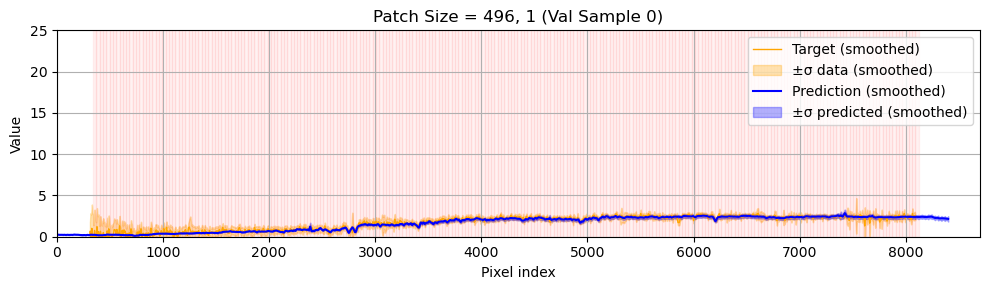

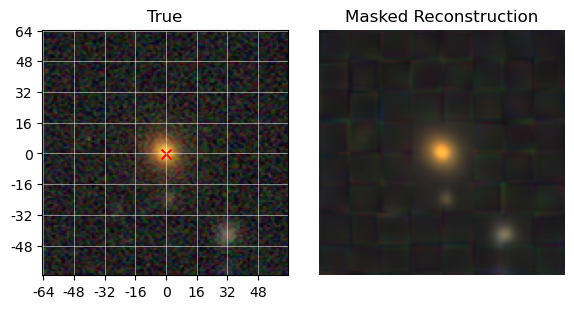

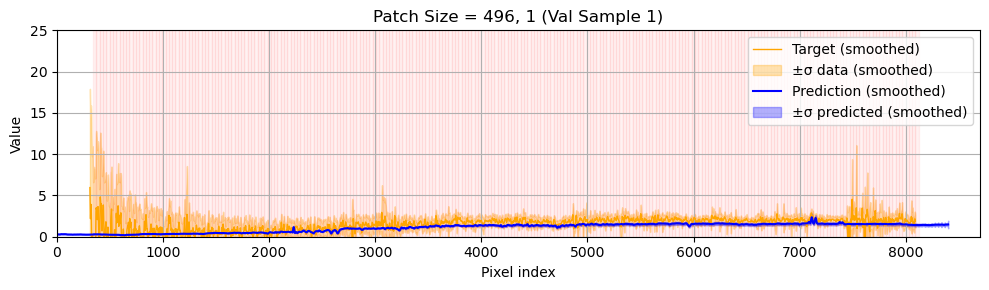

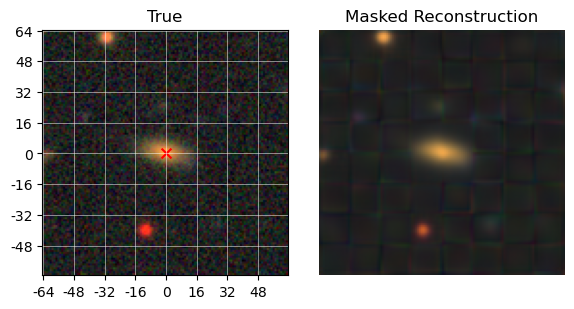

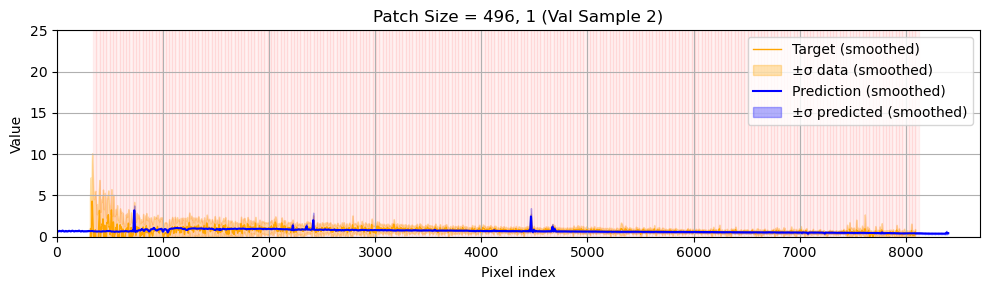

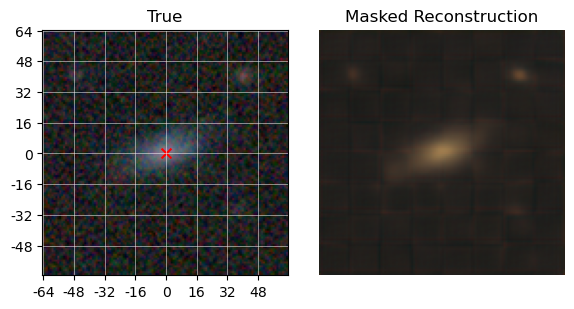

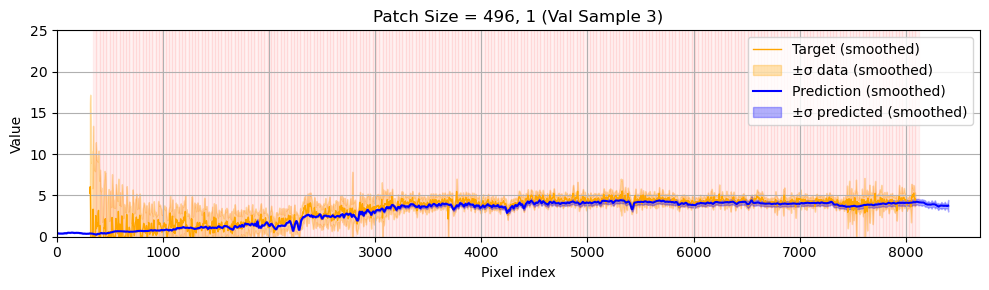

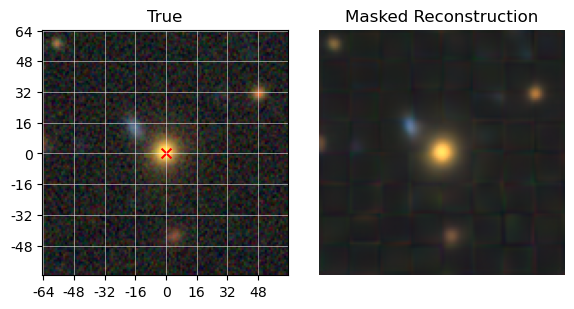

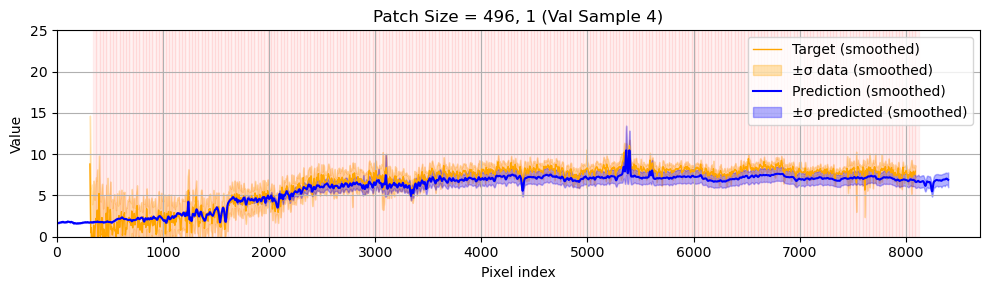

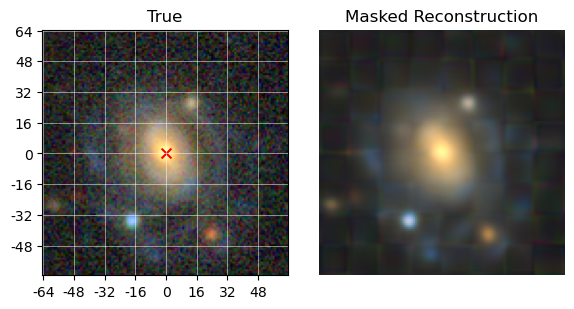

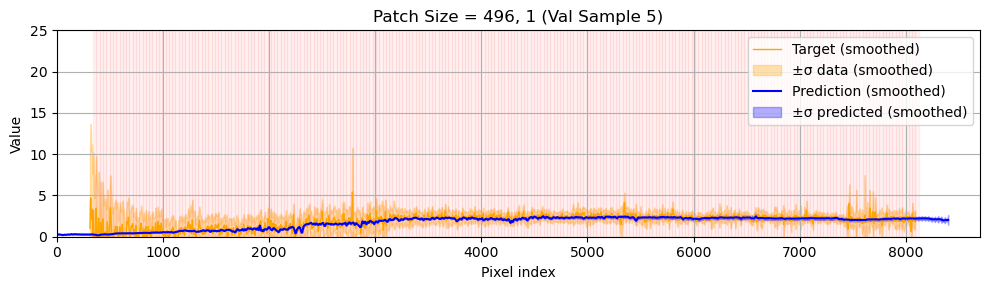

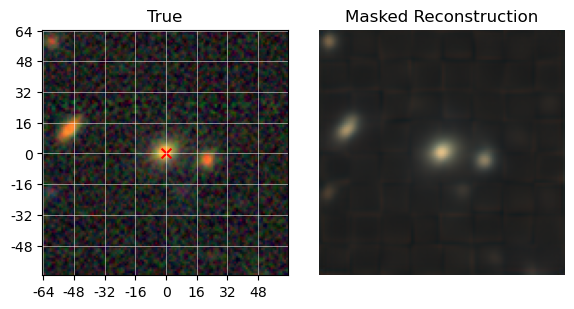

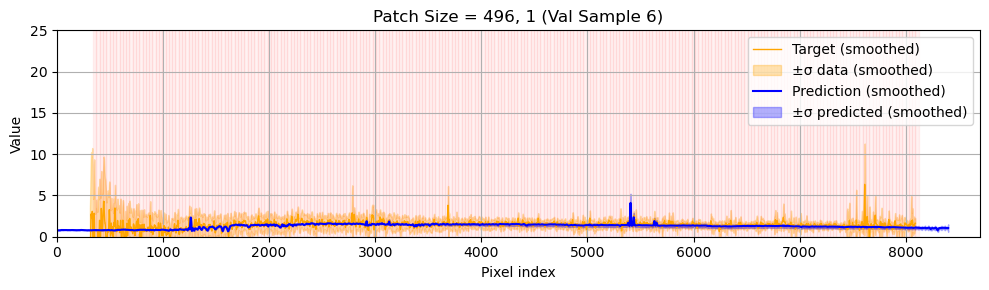

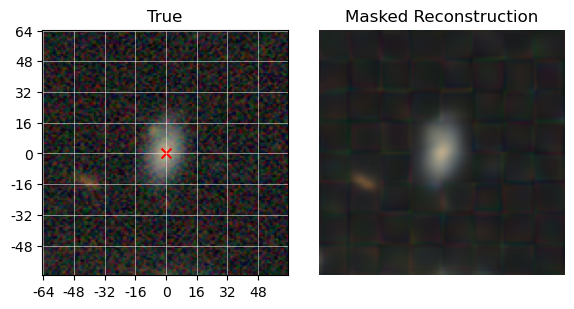

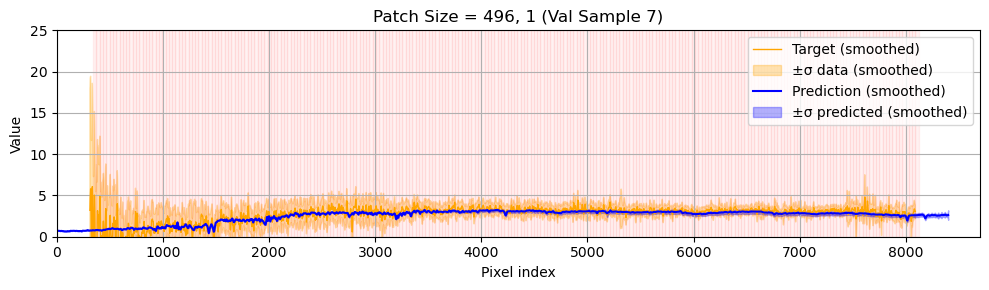

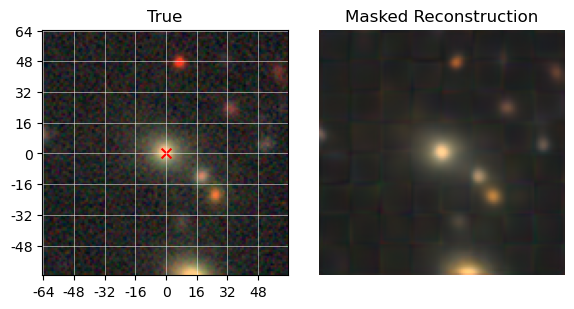

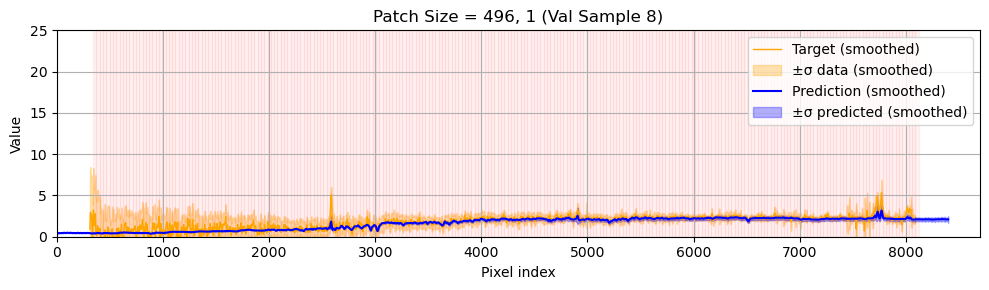

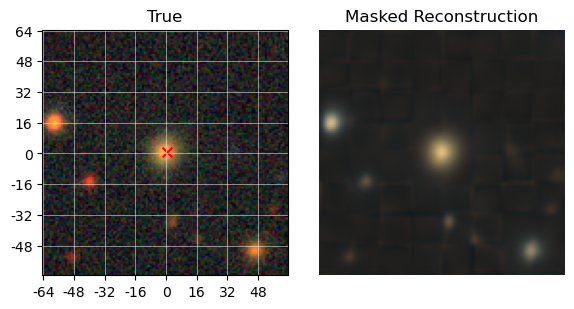

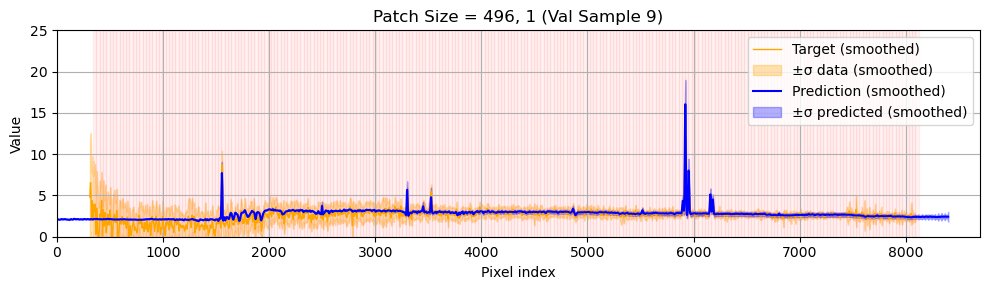

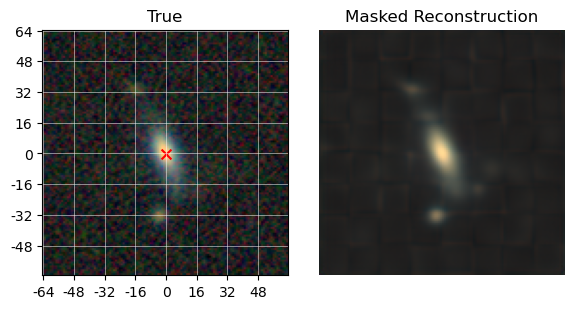

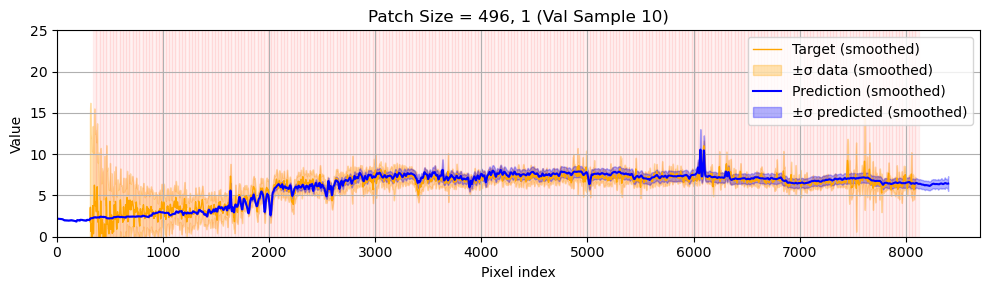

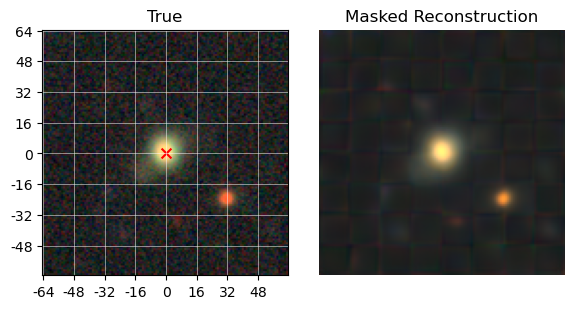

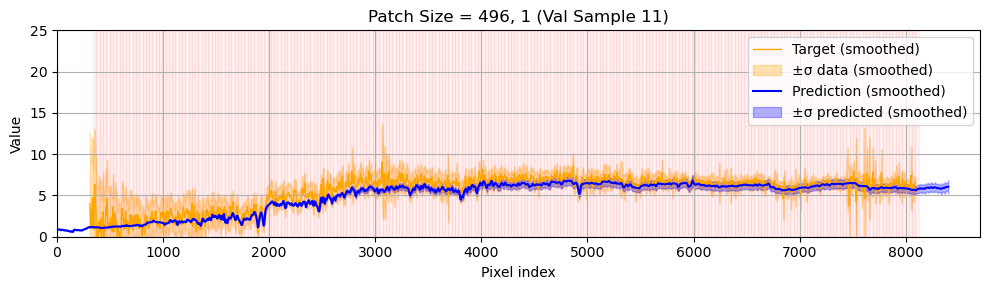

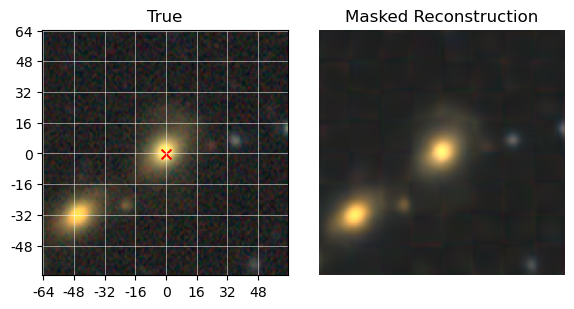

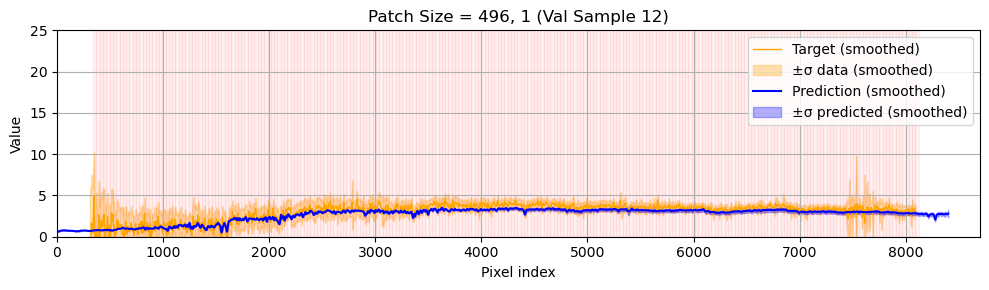

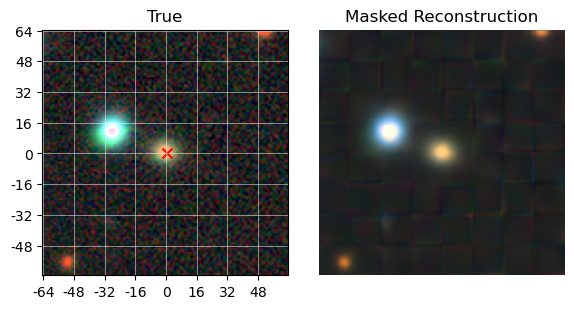

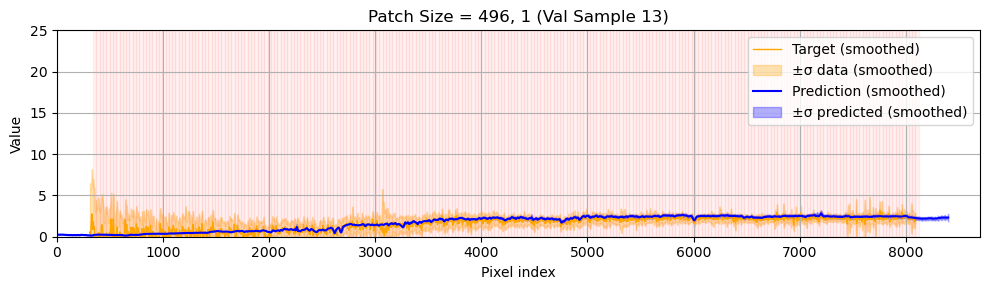

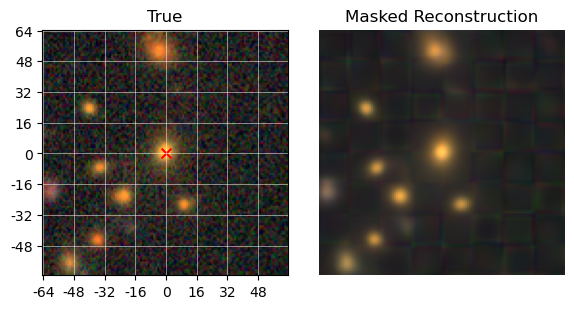

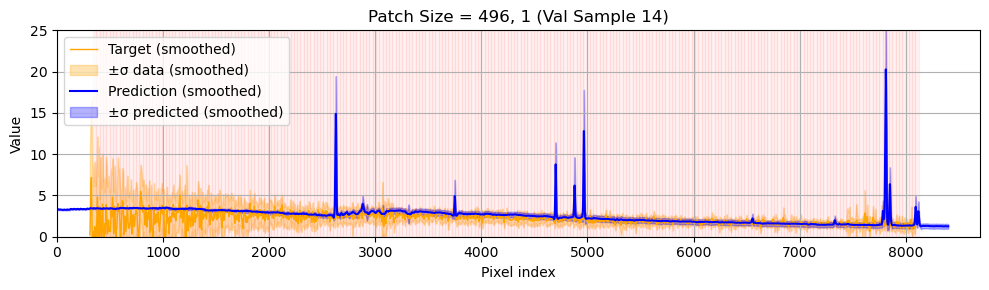

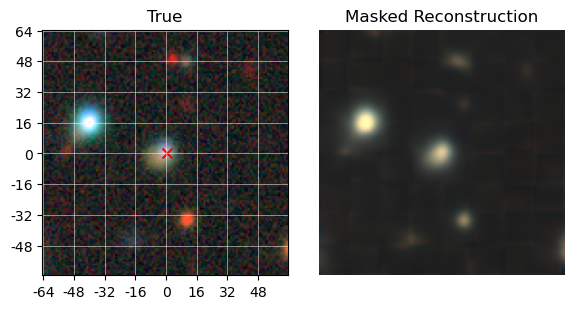

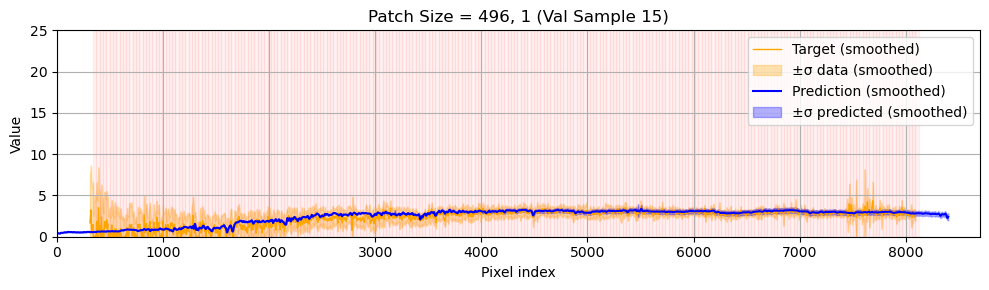

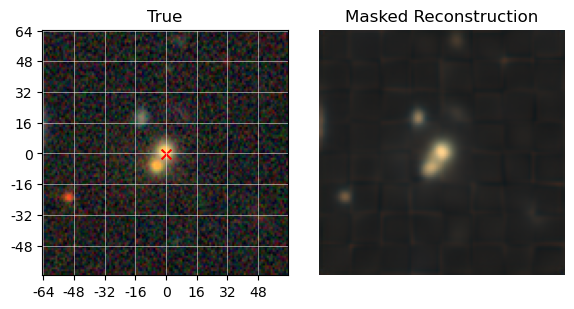

In [72]:
for i in range(16):
    visualize(model, spec, error, spec_pred, error_pred, img, pred_img, error_img, mask_spec, mask_img, xy_pix, i=i, ylims=(0,25))
# visualize(model, spec, error, spec_pred, error_pred, img, pred_img, error_img, mask_spec, mask_img, xy_pix, i=9, xlims=(5800, 6200), ylims=(0,25), nsmooth=1)

In [40]:
i = 6
pred_ch0 = pred_img[i].view(model.num_img_channels, gh, gw, model.img_patch, model.img_patch)[0]
pred_ch0 = pred_ch0.permute(0, 2, 1, 3).reshape(gh * model.img_patch, gw * model.img_patch).detach().cpu().numpy()

pred_ch1 = pred_img[i].view(model.num_img_channels, gh, gw, model.img_patch, model.img_patch)[1]
pred_ch1 = pred_ch1.permute(0, 2, 1, 3).reshape(gh * model.img_patch, gw * model.img_patch).detach().cpu().numpy()

pred_ch2 = pred_img[i].view(model.num_img_channels, gh, gw, model.img_patch, model.img_patch)[2]
pred_ch2 = pred_ch2.permute(0, 2, 1, 3).reshape(gh * model.img_patch, gw * model.img_patch).detach().cpu().numpy()

pred_ch3 = pred_img[i].view(model.num_img_channels, gh, gw, model.img_patch, model.img_patch)[3]
pred_ch3 = pred_ch3.permute(0, 2, 1, 3).reshape(gh * model.img_patch, gw * model.img_patch).detach().cpu().numpy()

pred_ch4 = pred_img[i].view(model.num_img_channels, gh, gw, model.img_patch, model.img_patch)[4]
pred_ch4 = pred_ch4.permute(0, 2, 1, 3).reshape(gh * model.img_patch, gw * model.img_patch).detach().cpu().numpy()

pred_ch5 = pred_img[i].view(model.num_img_channels, gh, gw, model.img_patch, model.img_patch)[5]
pred_ch5 = pred_ch5.permute(0, 2, 1, 3).reshape(gh * model.img_patch, gw * model.img_patch).detach().cpu().numpy()

pred_img_formatted = np.stack([pred_ch0, pred_ch1, pred_ch2, pred_ch3, pred_ch4, pred_ch5], axis=0)

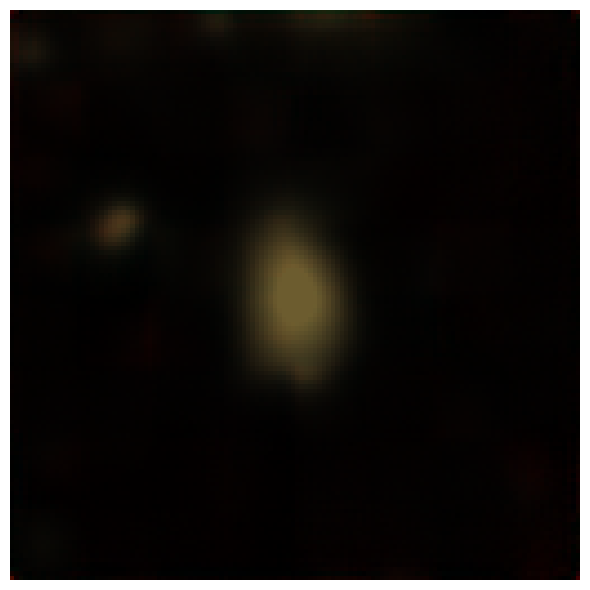

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import make_lupton_rgb

# pred_img_formatted has shape (6, 128, 128)
# channel order: g, r, i, z, W1, W2
g, r, i, z, w1, w2 = pred_img_formatted

# optional: robust background handling
def prep(x):
    x = np.asarray(x, dtype=float)
    lo, hi = np.nanpercentile(x, [1, 99.5])
    x = np.clip(x, lo, hi)
    x = x - lo
    return x

g_ = prep(g)
r_ = prep(r)
i_ = prep(i)

# nice-looking optical RGB: i/r/g -> R/G/B
rgb = make_lupton_rgb(i_, r_, g_, stretch=0.1, Q=8)

plt.figure(figsize=(6, 6))
plt.imshow(rgb, origin="lower")
plt.axis("off")
plt.tight_layout()
plt.show()

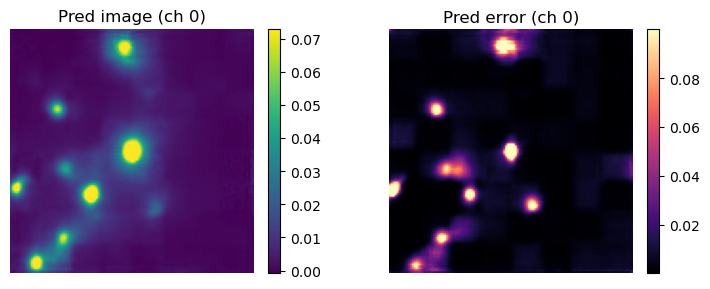

In [82]:
i = 13
ch = 3
N = model.patch_embedimg.num_patches
gh, gw = model.patch_embedimg.grid_size

pred_ch0 = pred_img[i].view(model.num_img_channels, gh, gw, model.img_patch, model.img_patch)[ch]
pred_ch0 = pred_ch0.permute(0, 2, 1, 3).reshape(gh * model.img_patch, gw * model.img_patch).detach().cpu().numpy()

err_ch0 = error_img[i].view(model.num_img_channels, gh, gw, model.img_patch, model.img_patch)[ch]
err_ch0 = np.exp(err_ch0.permute(0, 2, 1, 3).reshape(gh * model.img_patch, gw * model.img_patch).detach().cpu().numpy())

fig, axs = plt.subplots(1, 2, figsize=(8, 3))
im0 = axs[0].imshow(pred_ch0, cmap="viridis")
axs[0].set_title("Pred image (ch 0)")
axs[0].axis("off")
vmin, vmax = np.percentile(pred_ch0, [1, 99])
im0.set_clim(vmin, vmax)
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

im1 = axs[1].imshow(err_ch0, cmap="magma")
axs[1].set_title("Pred error (ch 0)")
axs[1].axis("off")
vmin, vmax = np.percentile(err_ch0, [1, 99])
im1.set_clim(vmin, vmax)
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [6]:
from models.MyTimm import Block, PatchEmbed1D

train_loader, val_loader = CreateMultimodalDataLoadersIter(end=100, train_size=70, batch_size=16)
batch = next(iter(train_loader))
x, s, weig, e, img, img_w, img_e, z, xy_pix = batch

s = model.patch_embed1d(s.unsqueeze(-1))
e = model.patch_embed1d(e.unsqueeze(-1))

# I'm going to hardcode 128 size assumption here for now
xy_grid_x = (xy_pix[:, 0] + 64.0) / model.img_patch
xy_grid_y = (64.0 - xy_pix[:, 1]) / model.img_patch
xy_grid = torch.stack([xy_grid_x, xy_grid_y], dim=-1)

xy_pe = model._continuous_2d_sincos(xy_grid, model.hparams.embed_dim, s.dtype, s.device).unsqueeze(1)

s = s + xy_pe
e = e + xy_pe

rel_coords = model._build_relative_patch_coords(xy_pix, dtype=img.dtype, device=img.device)
coord_emb = model.coord_mlp(rel_coords)
img = torch.cat([model.patch_embedimg(img[:, i:i + 1]) + coord_emb for i in range(img.size(1))], dim=1)
img_e = torch.cat([model.patch_embedimg(img_e[:, i:i + 1]) + coord_emb for i in range(img_e.size(1))], dim=1)

img_pos_embed = model.get_image_pos_embed(dtype=img.dtype, device=img.device)
img = img + img_pos_embed + model.img_modality_embed.to(dtype=img.dtype)
img_e = img_e + img_pos_embed + model.img_e_modality_embed.to(dtype=img_e.dtype)

deredshifted_start_indices, deredshifted_end_indices = generate_rest_indices(s, z, patch_size=model.patch_size)
pos_table = model.pos_embed[:, 1:, :].squeeze(0)
pe_start = pos_table[deredshifted_start_indices]
pe_end = pos_table[deredshifted_end_indices]
s = s + pe_start + pe_end
e = e + pe_start + pe_end

token_mask = generate_attn_mask(model.chunk_size, model.mask_ratio, model.num_patches1d, device=s.device)
token_mask_img = generate_attn_mask(1, model.mask_ratio_img, model.num_patchesimg, device=s.device)

In [40]:
token_mask.sum(), token_mask_img.sum()

(tensor(63), tensor(96))

In [41]:
s = s[:, (token_mask), :]
e = e[:, (token_mask), :]
img = img[:, (token_mask_img), :]
img_e = img_e[:, (token_mask_img), :]

cls_token = model.cls_token + model.pos_embed[:, 0, :]
cls_tokens = cls_token.expand(s.shape[0], -1, -1)
s = torch.cat((cls_tokens, s), dim=1)
e = torch.cat((cls_tokens, e), dim=1)

for blk in model.s_attn:
    s = blk(s)
s = model.norm(s)

for blk in model.e_attn:
    e = blk(e)
e = model.norm(e)

for blk in model.img_attn:
    img = blk(img)
img = model.norm(img)

for blk in model.img_e_attn:
    img_e = blk(img_e)
img_e = model.norm(img_e)

x = torch.cat([s, e], dim=-1)
x_img = torch.cat([img, img_e], dim=-1)
x = torch.cat([x, x_img], dim=1)

for blk in model.merged_blocks:
    x = blk(x)
x = model.merged_norm(x)

overall_token_mask = torch.cat([token_mask, token_mask_img], dim=0)

In [42]:
x = model.decoder_embed(x)

token_mask = overall_token_mask
spec_mask = token_mask[:-model.num_patchesimg]
img_mask = token_mask[-model.num_patchesimg:]

In [43]:
num_unmasked_img = img_mask.sum().item()
cls_token = x[:, 0, :]
spec_tokens = x[:, 1:-num_unmasked_img, :]
img_tokens = x[:, -num_unmasked_img:, :]
# Gathering unmasked tokens

In [49]:
x_spec = torch.zeros(x.shape[0], model.num_patches1d, x.shape[-1]) # B, L_spec, D
x_spec[:, spec_mask, :] = spec_tokens
x_spec[:, ~spec_mask, :] = model.spec_mask_token

x_img = torch.zeros(x.shape[0], model.num_patchesimg, x.shape[-1]) # B, L_img, D
x_img[:, img_mask, :] = img_tokens
x_img[:, ~img_mask, :] = model.img_mask_token
x = torch.cat([cls_token, x_spec, x_img], dim=1)

In [58]:
prob = 0.7/15

model = MaskedAutoencoderViT(spec_dim=7781,
        max_epochs=600,
        warmup_epoch=5,
        mask_ratio=0.75,
        embed_dim        = 256,
        merged_depth     = 4,
        merged_num_heads = 8,
        s_depth          = 4,
        e_depth          = 4,
        s_num_heads      = 8,
        e_num_heads      = 8,
        decoder_embed_dim= 512,
        decoder_depth    = 8,
        decoder_num_heads= 16,
        decoder_MLP_coefficient = 1,
        patch_scheme={
            "patch_sizes": [1, 1, 2, 4, 8, 16, 32, 64, 128, 64, 32, 16, 8, 4, 2, 1],
            "mask_ratios": [1, 0.9, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.2, 0.1, 0.0],
            "probs": [0.3, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob]
        })

In [59]:
x, spec, weig, error, img, img_w, img_e, z, xy_pix = batch
spec_loss, img_loss, total_loss, _, _, _, _, _ = model.forward(spec, weig, error, img, img_w, img_e, z, xy_pix)

RuntimeError: shape mismatch: value tensor of shape [16, 0, 512] cannot be broadcast to indexing result of shape [16, 0, 251, 512]

In [57]:
import math
import random

import numpy as np
import pytorch_lightning as pl
import torch
import torch.nn as nn
from timm.models.vision_transformer import PatchEmbed

from losses.SpecLoss import forward_loss
from models.MyTimm import Block, generate_attn_mask, PatchEmbed1D
from utils.DataProcessing import generate_rest_indices
from utils.PositionalEmbedding import get_1d_sincos_pos_embed, get_2d_sincos_pos_embed
from utils.Scheduler import CosineWarmupScheduler
from utils.Visualization import visualize


class MaskedAutoencoderViT(pl.LightningModule):
    """ Masked Autoencoder with VisionTransformer backbone, copied from https://github.com/facebookresearch/mae/blob/main/models_mae.py 
    """

    def __init__(
        self,
        spec_dim=7781,
        patch_size=31,
        left_patches=10,
        right_patches=10,
        embed_dim=768,
        merged_depth=6,
        merged_num_heads=6,
        s_depth=1,
        e_depth=1,
        s_num_heads=1,
        e_num_heads=1,
        decoder_embed_dim=384,
        decoder_depth=2,
        decoder_num_heads=6,
        decoder_MLP_coefficient=4,
        lr=2e-4,
        warmup_epoch=100,
        max_epochs=3000,
        batch_size=16,
        mlp_ratio=4.0,
        mask_ratio=0.75,
        patch_scheme={"patch_sizes": [1], "mask_ratios": [0.75]},
        scatter_term=1,
        log_regularizer=1.0,
        lam_grad=0.0,
        lam_curv=0.0,
        lam_fft=0.0,
        lam_topk=0.0,
        topk_frac=0.10,
        lam_spiky=0.0,
        spiky_tau=0.8,
        lam_under=0.0,
        lam_sigma_right=0.0,
        sigma_quantile=0.75,
        lam_img_sigma_masked=0.0,
        norm_layer=nn.LayerNorm,
        norm_pix_loss=False,
    ):
        super().__init__()
        self.save_hyperparameters()

        # --------------------------------------------------------------------------
        # MAE encoder specifics
        self.patch_embed1d = PatchEmbed1D(spec_dim, patch_size, embed_dim)
        self.img_patch = 16
        self.num_img_channels = 6
        self.patch_embedimg = PatchEmbed(img_size=128, patch_size=self.img_patch, in_chans=1, embed_dim=embed_dim)
        self.num_patches1d = self.patch_embed1d.num_patches
        self.num_patchesimg = self.patch_embedimg.num_patches * self.num_img_channels
        self.left_patches = left_patches
        self.right_patches = right_patches

        # --- image positional embeddings (spatial + channel + modality) ---
        self.num_img_spatial = self.patch_embedimg.num_patches
        img_grid_size = int(math.sqrt(self.num_img_spatial))
        if img_grid_size * img_grid_size != self.num_img_spatial:
            raise ValueError(f"Image patch grid is not square: {self.num_img_spatial}")

        self.register_buffer(
            "img_channel_embed",
            self._build_fixed_channel_embed(self.num_img_channels, embed_dim),
            persistent=False,
        )
        self.img_modality_embed = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.img_e_modality_embed = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.register_buffer(
            "img_spatial_pos_embed",
            get_2d_sincos_pos_embed(embed_dim, img_grid_size, img_grid_size),
            persistent=False,
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 10000 + 1, embed_dim), requires_grad=False)

        self.s_attn = nn.ModuleList([
            Block(embed_dim, s_num_heads, mlp_ratio, qkv_bias=True, norm_layer=norm_layer)
            for _ in range(s_depth)
        ])
        self.e_attn = nn.ModuleList([
            Block(embed_dim, e_num_heads, mlp_ratio, qkv_bias=True, norm_layer=norm_layer)
            for _ in range(e_depth)
        ])
        self.img_attn = nn.ModuleList([
            Block(embed_dim, s_num_heads, mlp_ratio, qkv_bias=True, norm_layer=norm_layer)
            for _ in range(s_depth)
        ])
        self.img_e_attn = nn.ModuleList([
            Block(embed_dim, e_num_heads, mlp_ratio, qkv_bias=True, norm_layer=norm_layer)
            for _ in range(e_depth)
        ])

        self.merged_blocks = nn.ModuleList([
            Block(2 * embed_dim, merged_num_heads, mlp_ratio, qkv_bias=True, norm_layer=norm_layer)
            for _ in range(merged_depth)
        ]) # Attention blocks for merged spectra and images
        self.norm = norm_layer(embed_dim)
        self.merged_norm = norm_layer(2 * embed_dim)
        # --------------------------------------------------------------------------

        # --------------------------------------------------------------------------
        # MAE decoder specifics
        self.decoder_embed = nn.Linear(embed_dim * 2, decoder_embed_dim, bias=True)

        self.spec_mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.img_mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))

        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, 10000 + 1, decoder_embed_dim), requires_grad=False)

        # --- decoder image positional embeddings (spatial + channel + modality) ---
        self.register_buffer(
            "decoder_img_channel_embed",
            self._build_fixed_channel_embed(self.num_img_channels, decoder_embed_dim),
            persistent=False,
        )
        self.decoder_img_modality_embed = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.register_buffer(
            "decoder_img_spatial_pos_embed",
            get_2d_sincos_pos_embed(decoder_embed_dim, img_grid_size, img_grid_size),
            persistent=False,
        )

        self.decoder_blocks = nn.ModuleList([
            Block(decoder_embed_dim, decoder_num_heads, mlp_ratio, qkv_bias=True, norm_layer=norm_layer)
            for _ in range(decoder_depth)
        ])

        self.decoder_norm = norm_layer(decoder_embed_dim)
        self.decoder_pred = nn.Sequential(
            nn.Linear(decoder_embed_dim, decoder_MLP_coefficient * decoder_embed_dim),
            nn.GELU(),
            nn.Linear(decoder_MLP_coefficient * decoder_embed_dim, decoder_MLP_coefficient * decoder_embed_dim),
            nn.GELU(),
            nn.Linear(decoder_MLP_coefficient * decoder_embed_dim, patch_size),
        )

        self.decoder_e_estimator = nn.Sequential(
            nn.Linear(decoder_embed_dim, decoder_MLP_coefficient * decoder_embed_dim),
            nn.GELU(),
            nn.Linear(decoder_MLP_coefficient * decoder_embed_dim, decoder_MLP_coefficient * decoder_embed_dim),
            nn.GELU(),
            nn.Linear(decoder_MLP_coefficient * decoder_embed_dim, patch_size),
        )

        self.decoder_pred_img = nn.Sequential(
            nn.Linear(decoder_embed_dim, decoder_MLP_coefficient * decoder_embed_dim),
            nn.GELU(),
            nn.Linear(decoder_MLP_coefficient * decoder_embed_dim, decoder_MLP_coefficient * decoder_embed_dim),
            nn.GELU(),
            nn.Linear(decoder_MLP_coefficient * decoder_embed_dim, self.img_patch * self.img_patch),
        )

        self.decoder_pred_img_e = nn.Sequential(
            nn.Linear(decoder_embed_dim, decoder_MLP_coefficient * decoder_embed_dim),
            nn.GELU(),
            nn.Linear(decoder_MLP_coefficient * decoder_embed_dim, decoder_MLP_coefficient * decoder_embed_dim),
            nn.GELU(),
            nn.Linear(decoder_MLP_coefficient * decoder_embed_dim, self.img_patch * self.img_patch),
        )

        refiner_hidden = 32
        self.decoder_img_refiner = nn.Sequential(
            nn.Conv2d(self.num_img_channels, refiner_hidden, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(refiner_hidden, refiner_hidden, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(refiner_hidden, refiner_hidden, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(refiner_hidden, self.num_img_channels, kernel_size=3, padding=1),
        )
        self.decoder_img_e_refiner = nn.Sequential(
            nn.Conv2d(self.num_img_channels, refiner_hidden, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(refiner_hidden, refiner_hidden, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(refiner_hidden, refiner_hidden, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(refiner_hidden, self.num_img_channels, kernel_size=3, padding=1),
        )
        # --------------------------------------------------------------------------

        self.norm_pix_loss = norm_pix_loss
        self.mask_ratio = mask_ratio
        self.mask_ratio_img = 0.75
        self.lr = lr
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.chunk_size = 1
        self.patch_scheme = patch_scheme
        self.warmup_epoch = warmup_epoch

        self.lambda_min_obs = 3600 - 0.8 * self.patch_size * self.left_patches
        self.lambda_max_obs = 9824 + 0.8 * self.patch_size * self.right_patches
        self.spec_dim = spec_dim

        # ---------------------------------------------------------------------------
        # Loss function parameters
        self.scatter_term = scatter_term
        self.log_regularizer = log_regularizer
        self.lam_grad = lam_grad
        self.lam_curv = lam_curv
        self.lam_fft = lam_fft
        self.lam_topk = lam_topk
        self.topk_frac = topk_frac
        self.lam_spiky = lam_spiky
        self.spiky_tau = spiky_tau
        self.lam_under = lam_under
        self.lam_sigma_right = lam_sigma_right
        self.sigma_quantile = sigma_quantile
        self.lam_img_sigma_masked = lam_img_sigma_masked

        # extras

        self.coord_mlp = nn.Sequential(
            nn.Linear(2, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, embed_dim),
        )
        self.decoder_coord_mlp = nn.Sequential(
            nn.Linear(2, decoder_embed_dim),
            nn.GELU(),
            nn.Linear(decoder_embed_dim, decoder_embed_dim),
        )

        self.img_spatial_pos_embed = get_2d_sincos_pos_embed(self.hparams.embed_dim, img_grid_size, img_grid_size)
        self.decoder_img_spatial_pos_embed = get_2d_sincos_pos_embed(
            self.hparams.decoder_embed_dim, img_grid_size, img_grid_size
        )

        self.initialize_weights()

    def initialize_weights(self):
        ###
        pos_embed = get_1d_sincos_pos_embed(self.pos_embed.shape[-1], 10000, cls_token=True)
        self.pos_embed.data.copy_(torch.from_numpy(pos_embed).float().unsqueeze(0))

        decoder_pos_embed = get_1d_sincos_pos_embed(self.decoder_pos_embed.shape[-1], 10000, cls_token=True)
        self.decoder_pos_embed.data.copy_(torch.from_numpy(decoder_pos_embed).float().unsqueeze(0))
        ### freeze sin cos PE

        # initialization
        # initialize patch_embed like nn.Linear (instead of nn.Conv2d)
        w = self.patch_embed1d.proj.weight.data
        torch.nn.init.xavier_uniform_(w.view([w.shape[0], -1]))

        # timm's trunc_normal_(std=.02) is effectively normal_(std=0.02) as cutoff is too big (2.)
        torch.nn.init.normal_(self.cls_token, std=0.02)
        torch.nn.init.normal_(self.spec_mask_token, std=0.02)
        torch.nn.init.normal_(self.img_mask_token, std=0.02)

        # torch.nn.init.normal_(self.img_channel_embed.weight, std=.02)
        torch.nn.init.normal_(self.img_modality_embed, std=0.02)
        torch.nn.init.normal_(self.img_e_modality_embed, std=0.02)
        # torch.nn.init.normal_(self.decoder_img_channel_embed.weight, std=.02)
        torch.nn.init.normal_(self.decoder_img_modality_embed, std=0.02)

        # initialize nn.Linear and nn.LayerNorm
        self.apply(self._init_weights)

    def _build_fixed_channel_embed(self, num_channels, embed_dim):
        if embed_dim % 2 != 0:
            raise ValueError(f"embed_dim must be even for fixed channel embeddings, got {embed_dim}")
        channel_ids = torch.arange(num_channels, dtype=torch.float32).unsqueeze(1)
        dim_half = embed_dim // 2
        omega = torch.arange(dim_half, dtype=torch.float32)
        omega = 1.0 / (10000.0 ** (omega / dim_half))
        out = channel_ids * omega.unsqueeze(0)
        return torch.cat([torch.sin(out), torch.cos(out)], dim=1)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            # we use xavier_uniform following official JAX ViT:
            torch.nn.init.xavier_uniform_(m.weight)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def get_image_pos_embed(self, dtype, device):
        spatial = self.img_spatial_pos_embed.to(device=device, dtype=dtype)
        spatial = spatial.expand(self.num_img_channels, -1, -1)

        channel = self.img_channel_embed.to(device=device, dtype=dtype)
        channel = channel.unsqueeze(1).expand(-1, self.num_img_spatial, -1)

        img_pos = (spatial + channel).reshape(1, self.num_img_channels * self.num_img_spatial, -1)
        return img_pos

    def get_decoder_image_pos_embed(self, dtype, device):
        spatial = self.decoder_img_spatial_pos_embed.to(device=device, dtype=dtype)
        spatial = spatial.expand(self.num_img_channels, -1, -1)

        channel = self.decoder_img_channel_embed.to(device=device, dtype=dtype)
        channel = channel.unsqueeze(1).expand(-1, self.num_img_spatial, -1)

        img_pos = (spatial + channel).reshape(1, self.num_img_channels * self.num_img_spatial, -1)
        return img_pos

    def _continuous_2d_sincos(self, xy_patch_units, embed_dim, dtype, device):
        # Used to generate PEs for spectrum based on fibre location, to match image sin cos PE
        if embed_dim % 4 != 0:
            raise ValueError(f"embed_dim must be divisible by 4, got {embed_dim}")
        xy = xy_patch_units.to(device=device, dtype=dtype)
        x = xy[:, 0:1]
        y = xy[:, 1:2]
        dim_each = embed_dim // 4
        omega = torch.arange(dim_each, device=device, dtype=dtype)
        omega = 1.0 / (10000.0 ** (omega / dim_each))
        out_x = x * omega.unsqueeze(0)
        out_y = y * omega.unsqueeze(0)
        return torch.cat([torch.sin(out_x), torch.cos(out_x), torch.sin(out_y), torch.cos(out_y)], dim=-1)

    def _build_relative_patch_coords(self, xy_pix, dtype, device):
        # Returns relative coords of image patch to centre patch in patch units
        gh, gw = self.patch_embedimg.grid_size
        p_h, p_w = self.patch_embedimg.patch_size
        H, W = self.patch_embedimg.img_size

        row_centers = torch.arange(gh, device=device, dtype=dtype) * p_h + (p_h - 1) / 2.0
        col_centers = torch.arange(gw, device=device, dtype=dtype) * p_w + (p_w - 1) / 2.0

        x_centers = col_centers - (W - 1) / 2.0
        y_centers = (H - 1) / 2.0 - row_centers

        yy, xx = torch.meshgrid(y_centers, x_centers, indexing="ij")
        patch_xy = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=-1)

        xy = xy_pix.to(device=device, dtype=dtype)
        rel_xy = patch_xy.unsqueeze(0) - xy.unsqueeze(1)
        return rel_xy / float(p_w)

    def _img_tokens_to_image(self, tokens):
        B = tokens.shape[0]
        gh, gw = self.patch_embedimg.grid_size
        p_h, p_w = self.patch_embedimg.patch_size
        x = tokens.view(B, self.num_img_channels, gh * gw, p_h * p_w)
        x = x.view(B, self.num_img_channels, gh, gw, p_h, p_w)
        x = x.permute(0, 1, 2, 4, 3, 5).reshape(B, self.num_img_channels, gh * p_h, gw * p_w)
        return x

    def _image_to_img_tokens(self, img):
        B = img.shape[0]
        gh, gw = self.patch_embedimg.grid_size
        p_h, p_w = self.patch_embedimg.patch_size
        x = img.view(B, self.num_img_channels, gh, p_h, gw, p_w)
        x = x.permute(0, 1, 2, 4, 3, 5).reshape(B, self.num_img_channels, gh * gw, p_h * p_w)
        return x.reshape(B, self.num_patchesimg, p_h * p_w)

    def _refine_img_tokens(self, tokens, refiner):
        img = self._img_tokens_to_image(tokens)
        img = refiner(img)
        return self._image_to_img_tokens(img)

    def forward_encoder(self, s, e, img, img_e, z, xy_pix, mask_ratio, chunk_size):
        s = self.patch_embed1d(s.unsqueeze(-1))
        e = self.patch_embed1d(e.unsqueeze(-1))

        # I'm going to hardcode 128 size assumption here for now
        xy_grid_x = (xy_pix[:, 0] + 64.0) / self.img_patch
        xy_grid_y = (64.0 - xy_pix[:, 1]) / self.img_patch
        xy_grid = torch.stack([xy_grid_x, xy_grid_y], dim=-1)

        xy_pe = self._continuous_2d_sincos(xy_grid, self.hparams.embed_dim, s.dtype, s.device).unsqueeze(1)

        s = s + xy_pe
        e = e + xy_pe

        rel_coords = self._build_relative_patch_coords(xy_pix, dtype=img.dtype, device=img.device)
        coord_emb = self.coord_mlp(rel_coords)
        img = torch.cat([self.patch_embedimg(img[:, i:i + 1]) + coord_emb for i in range(img.size(1))], dim=1)
        img_e = torch.cat([self.patch_embedimg(img_e[:, i:i + 1]) + coord_emb for i in range(img_e.size(1))], dim=1)

        img_pos_embed = self.get_image_pos_embed(dtype=img.dtype, device=img.device)
        img = img + img_pos_embed + self.img_modality_embed.to(dtype=img.dtype)
        img_e = img_e + img_pos_embed + self.img_e_modality_embed.to(dtype=img_e.dtype)

        deredshifted_start_indices, deredshifted_end_indices = generate_rest_indices(s, z, patch_size=self.patch_size)
        pos_table = self.pos_embed[:, 1:, :].squeeze(0)
        pe_start = pos_table[deredshifted_start_indices]
        pe_end = pos_table[deredshifted_end_indices]
        s = s + pe_start + pe_end
        e = e + pe_start + pe_end

        token_mask = generate_attn_mask(self.chunk_size, self.mask_ratio, self.num_patches1d, device=s.device)
        token_mask_img = generate_attn_mask(1, self.mask_ratio_img, self.num_patchesimg, device=s.device)

        # Change: only keep unmasked tokens in the sequence, add cls token later
        s = s[:, (token_mask), :]
        e = e[:, (token_mask), :]
        img = img[:, (token_mask_img), :]
        img_e = img_e[:, (token_mask_img), :]

        cls_token = self.cls_token + self.pos_embed[:, 0, :]
        cls_tokens = cls_token.expand(s.shape[0], -1, -1)
        s = torch.cat((cls_tokens, s), dim=1)
        e = torch.cat((cls_tokens, e), dim=1)

        for blk in self.s_attn:
            s = blk(s)
        s = self.norm(s)

        for blk in self.e_attn:
            e = blk(e)
        e = self.norm(e)

        for blk in self.img_attn:
            img = blk(img)
        img = self.norm(img)

        for blk in self.img_e_attn:
            img_e = blk(img_e)
        img_e = self.norm(img_e)

        x = torch.cat([s, e], dim=-1)
        x_img = torch.cat([img, img_e], dim=-1)
        x = torch.cat([x, x_img], dim=1)

        overall_token_mask = torch.cat([token_mask, token_mask_img], dim=0)

        for blk in self.merged_blocks:
            x = blk(x)
        x = self.merged_norm(x)

        return x, overall_token_mask, deredshifted_start_indices, deredshifted_end_indices

    def forward_decoder(self, x, token_mask, z, xy_pix):
        x = self.decoder_embed(x)

        spec_mask = token_mask[:-model.num_patchesimg]
        img_mask = token_mask[-model.num_patchesimg:]

        num_unmasked_img = img_mask.sum().item()
        cls_token = x[:, 0, :]
        spec_tokens = x[:, 1:-num_unmasked_img, :]
        img_tokens = x[:, -num_unmasked_img:, :]
        # Gathering unmasked tokens
        x_spec = torch.zeros(x.shape[0], model.num_patches1d, x.shape[-1]) # B, L_spec, D
        x_spec[:, spec_mask, :] = spec_tokens
        x_spec[:, ~spec_mask, :] = model.spec_mask_token

        x_img = torch.zeros(x.shape[0], model.num_patchesimg, x.shape[-1]) # B, L_img, D
        x_img[:, img_mask, :] = img_tokens
        x_img[:, ~img_mask, :] = model.img_mask_token
        x = torch.cat([cls_token, x_spec, x_img], dim=1)

        B, _, _ = x.shape
        left_tokens = self.spec_mask_token.repeat(B, self.left_patches, 1)
        right_tokens = self.spec_mask_token.repeat(B, self.right_patches, 1)

        cls_token = x[:, :1, :]
        main_seq = x[:, 1:-self.num_patchesimg, :]
        img_seq = x[:, -self.num_patchesimg:, :]
        padded_seq = torch.cat([left_tokens, main_seq, right_tokens, img_seq], dim=1)
        x = torch.cat([cls_token, padded_seq], dim=1)

        pos_table = self.decoder_pos_embed[:, 1:, :].squeeze(0)

        spec_len = x.shape[1] - 1 - self.num_patchesimg
        x_spec = x[:, 1:1 + spec_len, :]
        x_img = x[:, -self.num_patchesimg:, :]

        x_for_pe = x[:, :1 + spec_len, :]
        deredshifted_start_indices, deredshifted_end_indices = generate_rest_indices(
            x_for_pe,
            z,
            lambda_min_obs=self.lambda_min_obs,
            patch_size=self.patch_size,
        )

        pe_start = pos_table[deredshifted_start_indices]
        pe_end = pos_table[deredshifted_end_indices]
        x_spec = x_spec + pe_start[:, 1:, :] + pe_end[:, 1:, :]
        xy_grid_x = (xy_pix[:, 0] + 64.0) / self.img_patch
        xy_grid_y = (64.0 - xy_pix[:, 1]) / self.img_patch
        xy_grid = torch.stack([xy_grid_x, xy_grid_y], dim=-1)
        xy_pe = self._continuous_2d_sincos(xy_grid, self.hparams.decoder_embed_dim, x.dtype, x.device).unsqueeze(1)
        x_spec = x_spec + xy_pe

        img_pos = self.get_decoder_image_pos_embed(dtype=x.dtype, device=x.device)
        rel_coords = self._build_relative_patch_coords(xy_pix, dtype=x.dtype, device=x.device)
        coord_emb = self.decoder_coord_mlp(rel_coords).repeat(1, self.num_img_channels, 1)
        x_img = x_img + img_pos + self.decoder_img_modality_embed.to(dtype=x.dtype) + coord_emb

        x = torch.cat([x[:, :1, :], x_spec, x_img], dim=1)

        for blk in self.decoder_blocks:
            x = blk(x)
        x = self.decoder_norm(x)

        s = self.decoder_pred(x[:, :-self.num_patchesimg, :])
        e = self.decoder_e_estimator(x[:, :-self.num_patchesimg, :])
        img = self.decoder_pred_img(x[:, -self.num_patchesimg:, :])
        img_e = self.decoder_pred_img_e(x[:, -self.num_patchesimg:, :])
        img = self._refine_img_tokens(img, self.decoder_img_refiner)
        img_e = self._refine_img_tokens(img_e, self.decoder_img_e_refiner)

        s = s[:, 1:, :].view(s.shape[0], -1)
        e = e[:, 1:, :].view(e.shape[0], -1)
        img = img.view(img.shape[0], -1)
        img_e = img_e.view(img_e.shape[0], -1)

        return s, e, img, img_e

    def forward(self, spec, weig, error, img, weig_img, error_img, z, xy_pix):
        latent, _, token_mask, _ = self.forward_encoder(
            spec, error, img, error_img, z, xy_pix, self.mask_ratio, self.chunk_size
        )
        pred, error, pred_img, error_img = self.forward_decoder(latent, token_mask, z, xy_pix)

        offset = self.left_patches * self.patch_size
        spec_loss, img_loss, total_loss = forward_loss(
            pred[:, offset:offset + self.spec_dim],
            spec,
            weig,
            error[:, offset:offset + self.spec_dim],
            pred_img,
            img,
            weig_img,
            error_img,
            token_mask[:-self.num_patchesimg].long(),
            img_mask=token_mask[-self.num_patchesimg:].long(),
            num_patches1d=self.num_patches1d,
            left_patches=self.left_patches,
            patch_size=self.patch_size,
            img_patch=self.img_patch,
            num_img_channels=self.num_img_channels,
            num_img_patches=self.patch_embedimg.num_patches,
            weight=self.scatter_term,
            regularizer=self.log_regularizer,
            lam_grad=self.lam_grad,
            lam_curv=self.lam_curv,
            lam_topk=self.lam_topk,
            lam_fft=self.lam_fft,
            topk_frac=self.topk_frac,
            lam_spiky=self.lam_spiky,
            spiky_tau=self.spiky_tau,
            lam_under=self.lam_under,
            lam_sigma_right=self.lam_sigma_right,
            lam_img_sigma_masked=self.lam_img_sigma_masked,
        )
        return spec_loss, img_loss, total_loss, pred, error, pred_img, error_img, token_mask

    def training_step(self, batch, batch_idx):
        zero_loss = sum((p.sum() * 0.0) for p in self.parameters() if p.requires_grad)

        if batch is None:
            print(f"Empty batch at step {batch_idx}; using zero loss")
            return zero_loss

        self.chunk_size, self.mask_ratio = self.sample_patching()
        _, mask_ratio_img = self.sample_patching()
        if mask_ratio_img == self.mask_ratio and mask_ratio_img == 1:
            mask_ratio_img = 0.9
        self.mask_ratio_img = mask_ratio_img
        self.log("chunk_size", self.chunk_size)
        self.log("mask_ratio", self.mask_ratio)
        self.log("mask_ratio_img", self.mask_ratio_img)

        x, spec, weig, error, img, img_w, img_e, z, xy_pix = batch
        spec_loss, img_loss, total_loss, _, _, _, _, _ = self.forward(spec, weig, error, img, img_w, img_e, z, xy_pix)

        if not torch.isfinite(total_loss):
            print(f"Non-finite loss at step {batch_idx}; using zero loss")
            return zero_loss

        self.log("train_loss", total_loss, on_step=True, on_epoch=True, prog_bar=True, sync_dist=True)
        self.log("spec_loss", spec_loss, on_step=True, on_epoch=True, prog_bar=False, sync_dist=True)
        self.log("img_loss", img_loss, on_step=True, on_epoch=True, prog_bar=False, sync_dist=True)
        self.log("grad_norm", self._grad_norm(), on_step=True, on_epoch=True, prog_bar=False, sync_dist=True)
        return total_loss

    def validation_step(self, batch, batch_idx):
        if batch is None:
            return None

        self.chunk_size, self.mask_ratio = self.sample_patching()
        _, mask_ratio_img = self.sample_patching()
        if mask_ratio_img == self.mask_ratio and mask_ratio_img == 1:
            mask_ratio_img = 0.9
        self.mask_ratio_img = mask_ratio_img

        x, spec, weig, error, img, img_w, img_e, z, xy_pix = batch
        spec_loss, img_loss, total_loss, spec_pred, error_pred, pred_img, error_img, token_mask = self.forward(
            spec, weig, error, img, img_w, img_e, z, xy_pix
        )

        self.log("val_loss", total_loss, on_step=True, on_epoch=True, prog_bar=True, sync_dist=True)
        self.log("val_spec_loss", spec_loss, on_step=True, on_epoch=True, prog_bar=False, sync_dist=True)
        self.log("val_img_loss", img_loss, on_step=True, on_epoch=True, prog_bar=False, sync_dist=True)

        if batch_idx == 0:
            token_mask = token_mask.unsqueeze(0).expand(spec.size(0), -1)
            mask_spec = token_mask[:, :-self.num_patchesimg].long()
            mask_img = token_mask[:, -self.num_patchesimg:].long()
            visualize(self, spec, error, spec_pred, error_pred, img, img_e, pred_img, error_img, mask_spec, mask_img)

        return total_loss

    def sample_patching(self):
        """
        Sample (patch_size, mask_ratio) such that each patch_size is always
        matched with its corresponding mask_ratio.

        Expected `self.patch_scheme` layout::

            self.patch_scheme = {
                "patch_sizes": [64, 128, 256],      # required
                "mask_ratios": [0.3, 0.5, 0.7],     # required
                "probs":       [0.2, 0.6, 0.2]      # optional weights, len = N
            }

        * If 'probs' is omitted, pairs are sampled uniformly.
        * All three lists (patch_sizes, mask_ratios, probs) must share length N.
        """
        sch = self.patch_scheme
        try:
            patch_sizes = sch["patch_sizes"]
            mask_ratios = sch["mask_ratios"]
        except KeyError as e:
            raise KeyError(f"Missing required key: {e.args[0]}")

        if len(patch_sizes) != len(mask_ratios):
            raise ValueError("patch_sizes and mask_ratios must have the same length")

        probs = sch.get("probs")
        if probs and len(probs) != len(patch_sizes):
            raise ValueError("probs length must match patch_sizes length")

        idx = random.choices(range(len(patch_sizes)), weights=probs, k=1)[0]
        return patch_sizes[idx], mask_ratios[idx]

    def _grad_norm(self):
        total_norm = 0.0
        for p in self.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2)
                total_norm += param_norm.item() ** 2
        return total_norm ** 0.5

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)

        # Run cosine schedule per optimizer step instead of per epoch.
        total_steps = int(getattr(self.trainer, "estimated_stepping_batches", self.max_epochs))
        total_steps = max(1, total_steps)
        warmup_steps = int(self.warmup_epoch * total_steps / max(1, int(self.max_epochs)))
        warmup_steps = max(0, min(warmup_steps, total_steps - 1))

        self.lr_scheduler = CosineWarmupScheduler(
            optimizer,
            warmup=warmup_steps,
            max_iters=total_steps,
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": self.lr_scheduler,
                "interval": "step",
                "frequency": 1,
            },
        }


## Validation for Canonical MAE-Style Masking

This block validates the recent masking refactor:
1. Encoder drops masked tokens (only visible tokens are processed).
2. Decoder reinserts masked tokens to recover full token lengths.
3. End-to-end forward pass remains finite and shape-consistent.


In [26]:
import importlib
import sys
import torch

repo_root = "/pscratch/sd/p/pzehao/MultiModal"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import models.MyTimm as MyTimm
import models.MAE as MAE_mod

# Ensure notebook uses latest on-disk code, not stale in-kernel module state.
importlib.reload(MyTimm)
MAE_mod = importlib.reload(MAE_mod)
MaskedAutoencoderViT = MAE_mod.MaskedAutoencoderViT


def run_masking_validation(device):
    torch.manual_seed(123)

    model = MaskedAutoencoderViT(
        spec_dim=7781,
        patch_size=31,
        left_patches=10,
        right_patches=10,
        embed_dim=64,
        merged_depth=1,
        merged_num_heads=4,
        s_depth=1,
        e_depth=1,
        s_num_heads=4,
        e_num_heads=4,
        decoder_embed_dim=32,
        decoder_depth=1,
        decoder_num_heads=4,
        decoder_MLP_coefficient=2,
        batch_size=2,
        mask_ratio=0.75,
    ).to(device)
    model.eval()

    B = 2
    spec = torch.randn(B, model.spec_dim, device=device)
    error = 0.05 + 0.01 * torch.rand(B, model.spec_dim, device=device)
    img = torch.randn(B, model.num_img_channels, 128, 128, device=device)
    img_e = 0.05 + 0.01 * torch.rand(B, model.num_img_channels, 128, 128, device=device)
    z = torch.rand(B, device=device) * 1.5
    xy_pix = torch.empty(B, 2, device=device).uniform_(-20.0, 20.0)

    with torch.no_grad():
        latent, _, token_mask, _, _ = model.forward_encoder(
            spec,
            error,
            img,
            img_e,
            z,
            xy_pix,
            model.mask_ratio,
            model.chunk_size,
        )

        assert token_mask.dim() == 1, f"Expected 1D token mask, got shape {tuple(token_mask.shape)}"
        assert token_mask[0].item() is False, "CLS token should never be masked"

        expected_visible = int((~token_mask).sum().item())
        assert latent.shape[1] == expected_visible, (
            f"Encoder should emit only visible tokens: got {latent.shape[1]}, expected {expected_visible}"
        )

        pred, pred_err, pred_img, pred_img_err = model.forward_decoder(latent, token_mask, z, xy_pix)

        expected_spec_len = (model.num_patches1d + model.left_patches + model.right_patches) * model.patch_size
        expected_img_len = model.num_patchesimg * model.img_patch * model.img_patch

        assert pred.shape == (B, expected_spec_len), f"Bad pred shape: {tuple(pred.shape)}"
        assert pred_err.shape == (B, expected_spec_len), f"Bad pred_err shape: {tuple(pred_err.shape)}"
        assert pred_img.shape == (B, expected_img_len), f"Bad pred_img shape: {tuple(pred_img.shape)}"
        assert pred_img_err.shape == (B, expected_img_len), f"Bad pred_img_err shape: {tuple(pred_img_err.shape)}"

        weig = torch.ones_like(spec)
        weig_img = torch.ones_like(img)
        spec_loss, img_loss, total_loss, *_ = model.forward(spec, weig, error, img, weig_img, img_e, z, xy_pix)

        assert torch.isfinite(spec_loss), "spec_loss is not finite"
        assert torch.isfinite(img_loss), "img_loss is not finite"
        assert torch.isfinite(total_loss), "total_loss is not finite"

        # Check two edge masking regimes for sequence accounting.
        model.mask_ratio = 0.0
        model.mask_ratio_img = 0.0
        latent_nomask, _, token_mask_nomask, _, _ = model.forward_encoder(
            spec,
            error,
            img,
            img_e,
            z,
            xy_pix,
            model.mask_ratio,
            model.chunk_size,
        )
        expected_visible_nomask = int((~token_mask_nomask).sum().item())
        assert latent_nomask.shape[1] == expected_visible_nomask

        model.mask_ratio = 0.95
        model.mask_ratio_img = 0.95
        latent_highmask, _, token_mask_highmask, _, _ = model.forward_encoder(
            spec,
            error,
            img,
            img_e,
            z,
            xy_pix,
            model.mask_ratio,
            model.chunk_size,
        )
        expected_visible_highmask = int((~token_mask_highmask).sum().item())
        assert latent_highmask.shape[1] == expected_visible_highmask

    return {
        "device": str(device),
        "visible_tokens_default": int((~token_mask).sum().item()),
        "total_tokens_default": int(token_mask.numel()),
        "visible_tokens_nomask": int((~token_mask_nomask).sum().item()),
        "total_tokens_nomask": int(token_mask_nomask.numel()),
        "visible_tokens_highmask": int((~token_mask_highmask).sum().item()),
        "total_tokens_highmask": int(token_mask_highmask.numel()),
        "spec_loss": float(spec_loss.detach().cpu()),
        "img_loss": float(img_loss.detach().cpu()),
        "total_loss": float(total_loss.detach().cpu()),
    }


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = run_masking_validation(device)
results

{'device': 'cuda',
 'visible_tokens_default': 160,
 'total_tokens_default': 636,
 'visible_tokens_nomask': 636,
 'total_tokens_nomask': 636,
 'visible_tokens_highmask': 33,
 'total_tokens_highmask': 636,
 'spec_loss': 0.6416987776756287,
 'img_loss': 0.604458212852478,
 'total_loss': 1.246156930923462}

In [27]:
import importlib
import torch

import models.MyTimm as MyTimm
import models.MAE as MAE_mod

importlib.reload(MyTimm)
MAE_mod = importlib.reload(MAE_mod)
MaskedAutoencoderViT = MAE_mod.MaskedAutoencoderViT


def run_encoder_length_trace(device):
    torch.manual_seed(999)

    model = MaskedAutoencoderViT(
        spec_dim=7781,
        patch_size=31,
        embed_dim=64,
        merged_depth=1,
        merged_num_heads=4,
        s_depth=1,
        e_depth=1,
        s_num_heads=4,
        e_num_heads=4,
        decoder_embed_dim=32,
        decoder_depth=1,
        decoder_num_heads=4,
        decoder_MLP_coefficient=2,
        batch_size=2,
        mask_ratio=0.80,
    ).to(device)
    model.mask_ratio_img = 0.70
    model.eval()

    B = 2
    spec = torch.randn(B, model.spec_dim, device=device)
    error = 0.05 + 0.01 * torch.rand(B, model.spec_dim, device=device)
    img = torch.randn(B, model.num_img_channels, 128, 128, device=device)
    img_e = 0.05 + 0.01 * torch.rand(B, model.num_img_channels, 128, 128, device=device)
    z = torch.rand(B, device=device)
    xy_pix = torch.empty(B, 2, device=device).uniform_(-10.0, 10.0)

    lengths = {}

    def hook(name):
        def _hook(_module, inputs, _output):
            lengths[name] = int(inputs[0].shape[1])
        return _hook

    handles = []
    handles.append(model.s_attn[0].register_forward_hook(hook("s_attn_in")))
    handles.append(model.e_attn[0].register_forward_hook(hook("e_attn_in")))
    handles.append(model.img_attn[0].register_forward_hook(hook("img_attn_in")))
    handles.append(model.img_e_attn[0].register_forward_hook(hook("img_e_attn_in")))
    handles.append(model.merged_blocks[0].register_forward_hook(hook("merged_in")))

    with torch.no_grad():
        latent, _, token_mask, _, _ = model.forward_encoder(
            spec,
            error,
            img,
            img_e,
            z,
            xy_pix,
            model.mask_ratio,
            model.chunk_size,
        )

    for h in handles:
        h.remove()

    spec_mask = token_mask[:-model.num_patchesimg]
    img_mask = token_mask[-model.num_patchesimg:]
    spec_visible = int((~spec_mask).sum().item())
    img_visible = int((~img_mask).sum().item())
    total_visible = int((~token_mask).sum().item())

    assert lengths["s_attn_in"] == spec_visible
    assert lengths["e_attn_in"] == spec_visible
    assert lengths["img_attn_in"] == img_visible
    assert lengths["img_e_attn_in"] == img_visible
    assert lengths["merged_in"] == total_visible
    assert latent.shape[1] == total_visible

    return {
        "spec_visible": spec_visible,
        "img_visible": img_visible,
        "total_visible": total_visible,
        "s_attn_in": lengths["s_attn_in"],
        "e_attn_in": lengths["e_attn_in"],
        "img_attn_in": lengths["img_attn_in"],
        "img_e_attn_in": lengths["img_e_attn_in"],
        "merged_in": lengths["merged_in"],
    }


trace = run_encoder_length_trace(device)
trace

{'spec_visible': 51,
 'img_visible': 115,
 'total_visible': 166,
 's_attn_in': 51,
 'e_attn_in': 51,
 'img_attn_in': 115,
 'img_e_attn_in': 115,
 'merged_in': 166}

In [25]:
import importlib
import torch

import models.MyTimm as MyTimm
import models.MAE as MAE_mod

importlib.reload(MyTimm)
MAE_mod = importlib.reload(MAE_mod)
MaskedAutoencoderViT = MAE_mod.MaskedAutoencoderViT


def run_real_batch_check(device):
    assert "batch" in globals(), "No 'batch' variable found in notebook state"

    x, spec, weig, error, img, img_w, img_e, z, xy_pix = batch
    spec = spec.to(device)
    weig = weig.to(device)
    error = error.to(device)
    img = img.to(device)
    img_w = img_w.to(device)
    img_e = img_e.to(device)
    z = z.to(device)
    xy_pix = xy_pix.to(device)

    model = MaskedAutoencoderViT(
        spec_dim=spec.shape[1],
        patch_size=31,
        embed_dim=64,
        merged_depth=1,
        merged_num_heads=4,
        s_depth=1,
        e_depth=1,
        s_num_heads=4,
        e_num_heads=4,
        decoder_embed_dim=32,
        decoder_depth=1,
        decoder_num_heads=4,
        decoder_MLP_coefficient=2,
        batch_size=spec.shape[0],
        mask_ratio=0.75,
    ).to(device)
    model.eval()

    with torch.no_grad():
        spec_loss, img_loss, total_loss, pred, pred_err, pred_img, pred_img_err, token_mask = model.forward(
            spec, weig, error, img, img_w, img_e, z, xy_pix
        )

    assert torch.isfinite(spec_loss)
    assert torch.isfinite(img_loss)
    assert torch.isfinite(total_loss)

    expected_spec_out = (model.num_patches1d + model.left_patches + model.right_patches) * model.patch_size
    expected_img_out = model.num_patchesimg * model.img_patch * model.img_patch

    assert pred.shape == (spec.shape[0], expected_spec_out)
    assert pred_err.shape == (spec.shape[0], expected_spec_out)
    assert pred_img.shape == (spec.shape[0], expected_img_out)
    assert pred_img_err.shape == (spec.shape[0], expected_img_out)
    assert token_mask.shape[0] == (model.num_patches1d + 1 + model.num_patchesimg)

    return {
        "batch_size": int(spec.shape[0]),
        "spec_len": int(spec.shape[1]),
        "img_shape": tuple(int(v) for v in img.shape),
        "spec_loss": float(spec_loss.detach().cpu()),
        "img_loss": float(img_loss.detach().cpu()),
        "total_loss": float(total_loss.detach().cpu()),
        "masked_tokens": int(token_mask.sum().item()),
        "total_tokens": int(token_mask.numel()),
    }


real_batch_result = run_real_batch_check(device)
real_batch_result

{'batch_size': 16,
 'spec_len': 7781,
 'img_shape': (16, 6, 128, 128),
 'spec_loss': 8.85388469696045,
 'img_loss': 11.035604476928711,
 'total_loss': 19.889488220214844,
 'masked_tokens': 476,
 'total_tokens': 636}

In [28]:
import importlib
import torch
import models.MAE as MAE_mod

MAE_mod = importlib.reload(MAE_mod)
MaskedAutoencoderViT = MAE_mod.MaskedAutoencoderViT

assert "checkpoint" in globals(), "checkpoint variable not found in notebook state"
ckpt = checkpoint

hparams = ckpt.get("hyper_parameters", {})
state_dict = ckpt["state_dict"]

fresh_model = MaskedAutoencoderViT(**hparams)

strict_ok = True
strict_error = None
try:
    fresh_model.load_state_dict(state_dict, strict=True)
except Exception as e:
    strict_ok = False
    strict_error = repr(e)

incompat = fresh_model.load_state_dict(state_dict, strict=False)

load_check = {
    "checkpoint_path": globals().get("path", "<unknown>"),
    "strict_ok": strict_ok,
    "strict_error": strict_error,
    "missing_keys_count": len(incompat.missing_keys),
    "unexpected_keys_count": len(incompat.unexpected_keys),
    "missing_keys_head": incompat.missing_keys[:10],
    "unexpected_keys_head": incompat.unexpected_keys[:10],
}

load_check

{'checkpoint_path': '/pscratch/sd/p/pzehao/DESIMAE/Final/epoch=097-val_loss=-2.2914.ckpt',
 'strict_ok': True,
 'strict_error': None,
 'missing_keys_count': 0,
 'unexpected_keys_count': 0,
 'missing_keys_head': [],
 'unexpected_keys_head': []}

In [38]:
import importlib
import sys
import torch

repo_root = "/pscratch/sd/p/pzehao/MultiModal"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import models.MyTimm as MyTimm
import models.MAE as MAE_mod

importlib.reload(MyTimm)
MAE_mod = importlib.reload(MAE_mod)
MaskedAutoencoderViT = MAE_mod.MaskedAutoencoderViT

# 1) Strict checkpoint load check (weights compatibility)
assert "checkpoint" in globals(), "checkpoint variable not found in notebook state"
ckpt = checkpoint
fresh_model = MaskedAutoencoderViT(**ckpt.get("hyper_parameters", {}))
incompat = fresh_model.load_state_dict(ckpt["state_dict"], strict=True)

# 2) New 2-value encoder signature + masking sanity
B = 2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
toy = MaskedAutoencoderViT(
    spec_dim=7781,
    patch_size=31,
    embed_dim=64,
    merged_depth=1,
    merged_num_heads=4,
    s_depth=1,
    e_depth=1,
    s_num_heads=4,
    e_num_heads=4,
    decoder_embed_dim=32,
    decoder_depth=1,
    decoder_num_heads=4,
    decoder_MLP_coefficient=2,
).to(device).eval()

spec = torch.randn(B, toy.spec_dim, device=device)
err = 0.05 + 0.01 * torch.rand(B, toy.spec_dim, device=device)
img = torch.randn(B, toy.num_img_channels, 128, 128, device=device)
img_e = 0.05 + 0.01 * torch.rand(B, toy.num_img_channels, 128, 128, device=device)
z = torch.rand(B, device=device)
xy = torch.empty(B, 2, device=device).uniform_(-20.0, 20.0)

with torch.no_grad():
    latent, token_mask = toy.forward_encoder(spec, err, img, img_e, z, xy, toy.mask_ratio, toy.chunk_size)
    pred, pred_err, pred_img, pred_img_err = toy.forward_decoder(latent, token_mask, z, xy)

out = {
    "strict_ok": True,
    "missing_keys": len(incompat.missing_keys),
    "unexpected_keys": len(incompat.unexpected_keys),
    "encoder_returns": 2,
    "visible_tokens": int((~token_mask).sum().item()),
    "total_tokens": int(token_mask.numel()),
    "latent_seq_len": int(latent.shape[1]),
    "pred_shape": tuple(int(v) for v in pred.shape),
    "pred_img_shape": tuple(int(v) for v in pred_img.shape),
}
out

{'strict_ok': True,
 'missing_keys': 0,
 'unexpected_keys': 0,
 'encoder_returns': 2,
 'visible_tokens': 159,
 'total_tokens': 636,
 'latent_seq_len': 159,
 'pred_shape': (2, 8401),
 'pred_img_shape': (2, 98304)}